## VALUE AT RISK

### 0. Library

In [1]:
# Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import chi2
warnings.filterwarnings('ignore')

### 1. Exploratory Analysis

#### 1.1 Fetch Financial Data

In [2]:
# Path
raw_folder=r'C:\Users\david\OneDrive\Escritorio\TRADING\Market_Risk\Projects\Project_1\data\raw'

# My assets
tickers=['GC=F','AAPL','NVDA','BTC-USD','SHY','GE','TLT','ETH-USD','VPU']
start_date='2020-01-01'
end_date='2025-12-31'
# Save each asset individually
for ticker in tickers:
    asset_data=yf.download(ticker,start=start_date,end=end_date)
    file_path=os.path.join(raw_folder,f"{ticker}_raw.csv")
    asset_data.to_csv(file_path)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


**Data Hole** ( Holidays where one asset has a price but another doesn't)

In [3]:
# We only need the Date and the Price
all_data={} # Dict with all the stocks

for ticker in tickers:
    file_path=os.path.join(raw_folder,f"{ticker}_raw.csv")
    
    if os.path.exists(file_path):
    
        df=pd.read_csv(file_path,skiprows=2)
        dates=pd.to_datetime(df.iloc[:,0],format='mixed',errors='coerce',dayfirst=True) # We extract the date. Any format type (format=mixed). errors=coerce, fill blank date, into NaT(Not a Time)
        prices=df.iloc[:,1] # We extract prices
        temp_series=pd.Series(data=prices.values,index=dates,name=ticker) # We create a temporary serie
        temp_series=temp_series[temp_series.index.notnull()] # Take only the only that are not null (so throw away NaT)
        all_data[ticker]=temp_series # Storage as a dict

    else:
        print('File not found for',ticker)
      
# Combine into one DataFrame
df_combined=pd.DataFrame(all_data).sort_index()
df_filled=df_combined.ffill().dropna() # Fill NaN with the future value, and drop the 01-01 (It was the New Year, and it was Nan also because it was the first row, so no ffill)
df_filled

,GC=F,AAPL,NVDA,BTC-USD,SHY,GE,TLT,ETH-USD,VPU
Date,,,,,,,,,
2020-01-02,1524.500000,72.333862,5.963803,6985.470215,72.893326,57.675587,112.883896,127.410179,115.459412
2020-01-03,1549.199951,71.630638,5.868347,7344.884277,72.953644,57.868965,114.622375,134.171707,115.492096
2020-01-04,1549.199951,71.630638,5.868347,7410.656738,72.953644,57.868965,114.622375,135.069366,115.492096
2020-01-05,1549.199951,71.630638,5.868347,7411.317383,72.953644,57.868965,114.622375,136.276779,115.492096
2020-01-06,1566.199951,72.201401,5.892957,7769.219238,72.927826,58.690834,113.971481,144.304153,115.721199
...,...,...,...,...,...,...,...,...,...
2025-12-26,4529.100098,272.893005,190.297897,87301.429688,81.353157,313.930847,85.794495,2925.745605,183.072281
2025-12-27,4529.100098,272.893005,190.297897,87802.156250,81.353157,313.930847,85.794495,2947.998291,183.072281
2025-12-28,4529.100098,272.893005,190.297897,87835.835938,81.353157,313.930847,85.794495,2948.568115,183.072281


#### 1.2 Log Returns

In [4]:
# Calculate daily Log returns 
daily_returns=np.log(df_filled/df_filled.shift(1)).dropna()

# Save it in a csv
processed_path=r'C:\Users\david\OneDrive\Escritorio\TRADING\Market_Risk\Projects\Project_1\data\processed\processed_returns.csv'
daily_returns.to_csv(processed_path)
daily_returns

,GC=F,AAPL,NVDA,BTC-USD,SHY,GE,TLT,ETH-USD,VPU
Date,,,,,,,,,
2020-01-03,0.016072,-0.009769,-0.016135,0.050172,0.000827,0.003347,0.015283,0.051709,0.000283
2020-01-04,0.000000,0.000000,0.000000,0.008915,0.000000,0.000000,0.000000,0.006668,0.000000
2020-01-05,0.000000,0.000000,0.000000,0.000089,0.000000,0.000000,0.000000,0.008899,0.000000
2020-01-06,0.010914,0.007937,0.004185,0.047161,-0.000354,0.014102,-0.005695,0.057235,0.001982
2020-01-07,0.003569,-0.004714,0.012034,0.049527,0.000000,-0.007441,-0.004928,-0.005282,-0.002549
...,...,...,...,...,...,...,...,...,...
2025-12-26,0.010766,-0.001498,0.010128,0.000764,0.000725,-0.005096,-0.003300,0.007605,-0.001239
2025-12-27,0.000000,0.000000,0.000000,0.005719,0.000000,0.000000,0.000000,0.007577,0.000000
2025-12-28,0.000000,0.000000,0.000000,0.000384,0.000000,0.000000,0.000000,0.000193,0.000000


In [5]:
# Sum of Monthly returns at the end of the month
monthly_returns=daily_returns.resample('ME').sum()
monthly_returns

,GC=F,AAPL,NVDA,BTC-USD,SHY,GE,TLT,ETH-USD,VPU
Date,,,,,,,,,
2020-01-31,0.037592,0.030042,-0.014612,0.291601,0.005301,0.042665,0.062868,0.346435,0.071634
2020-02-29,-0.011948,-0.121830,0.133627,-0.083728,0.008728,-0.134794,0.064162,0.199092,-0.105214
2020-03-31,0.012264,-0.072314,-0.024248,-0.289387,0.012364,-0.314020,0.061816,-0.498137,-0.106257
2020-04-30,0.061716,0.144424,0.103280,0.296230,0.002722,-0.154991,0.012116,0.440821,0.031803
2020-05-31,0.030811,0.081667,0.194462,0.088637,-0.000784,-0.034409,-0.017776,0.106690,0.042159
...,...,...,...,...,...,...,...,...,...
2025-08-31,0.053361,0.113006,-0.020964,-0.067183,0.008836,0.015084,0.000127,0.171891,-0.013861
2025-09-30,0.100460,0.092471,0.068827,0.052370,0.002873,0.090235,0.035280,-0.057200,0.042688
2025-10-31,0.036154,0.059980,0.081830,-0.040253,0.003332,0.026667,0.013717,-0.074819,0.019087


#### 1.3 Volatility (Risk Profiling)

In [6]:
# Daily volatility for each asset
df_volatility=np.std(daily_returns)
df_volatility

GC=F       0.008933
AAPL       0.016588
NVDA       0.027666
BTC-USD    0.032372
SHY        0.000963
GE         0.019921
TLT        0.008934
ETH-USD    0.043309
VPU        0.011592
dtype: float64

In [7]:
# Monthly volatility of each date(each month) Using monthly returns
monthly_ret=daily_returns.resample('ME') # It's an object
monthly_month_vola=monthly_ret.std()
monthly_month_vola

,GC=F,AAPL,NVDA,BTC-USD,SHY,GE,TLT,ETH-USD,VPU
Date,,,,,,,,,
2020-01-31,0.005189,0.014669,0.015589,0.027609,0.000414,0.023888,0.006448,0.036201,0.004097
2020-02-29,0.011488,0.019958,0.032900,0.025718,0.000848,0.020523,0.007356,0.048156,0.012255
2020-03-31,0.022080,0.054543,0.068951,0.101122,0.001776,0.067831,0.031519,0.120709,0.055648
2020-04-30,0.013547,0.025240,0.036456,0.034906,0.000410,0.040502,0.009275,0.050215,0.028964
2020-05-31,0.008626,0.009897,0.022138,0.033651,0.000396,0.038505,0.008083,0.038485,0.014512
...,...,...,...,...,...,...,...,...,...
2025-08-31,0.007315,0.014935,0.013395,0.018759,0.001073,0.011462,0.004838,0.047395,0.005958
2025-09-30,0.007734,0.015044,0.016972,0.012782,0.000500,0.012136,0.005882,0.026037,0.006613
2025-10-31,0.018125,0.012355,0.019543,0.022683,0.000718,0.012639,0.004801,0.039752,0.006932


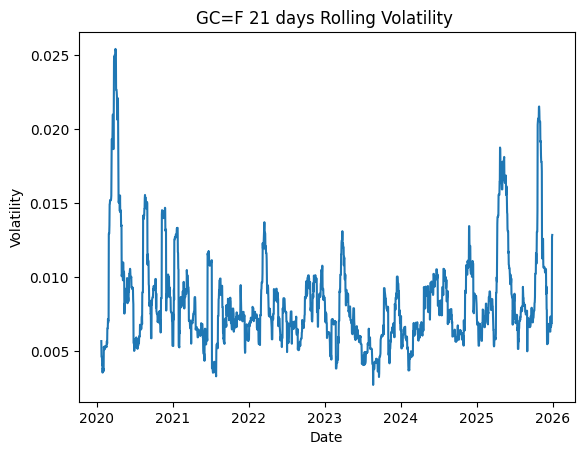

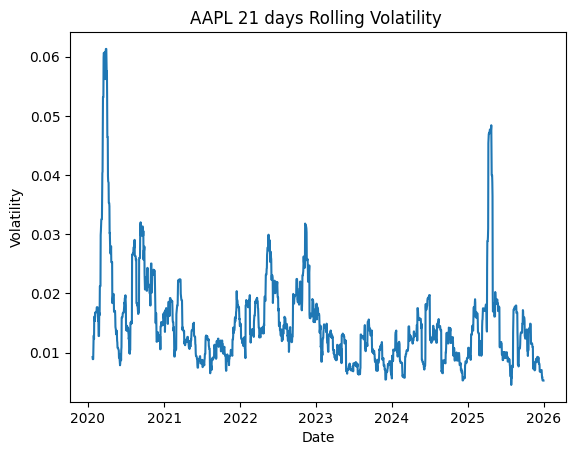

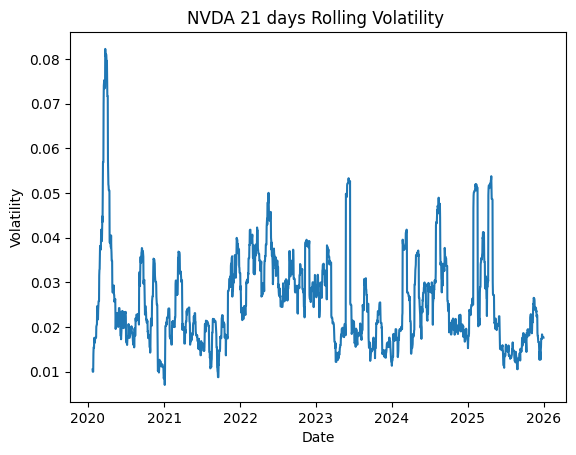

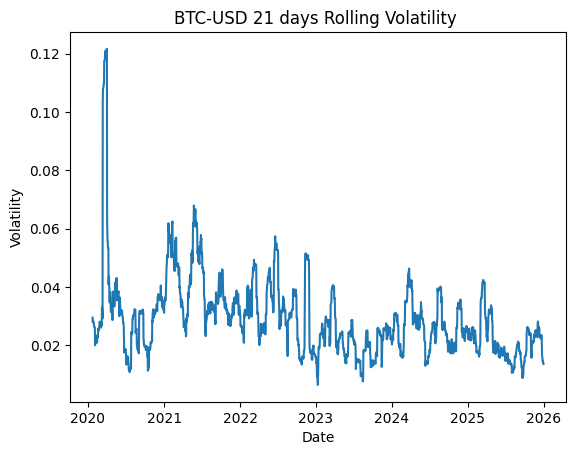

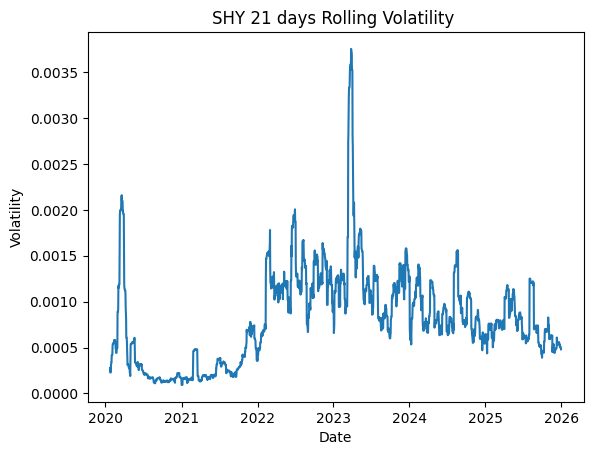

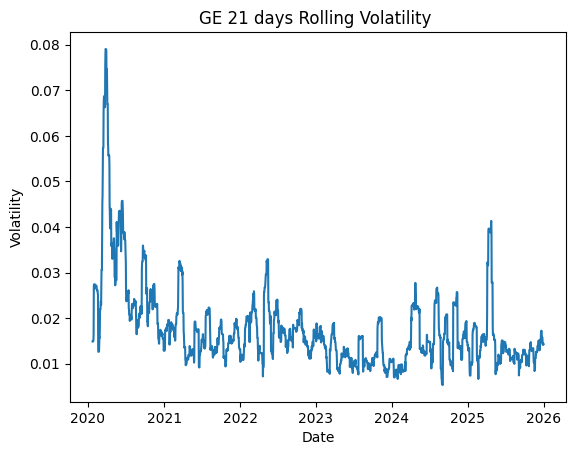

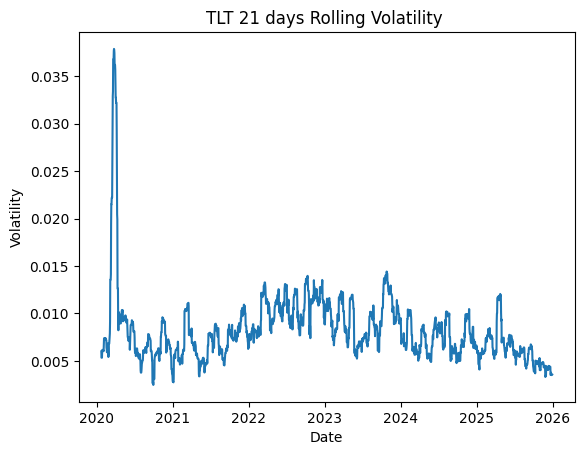

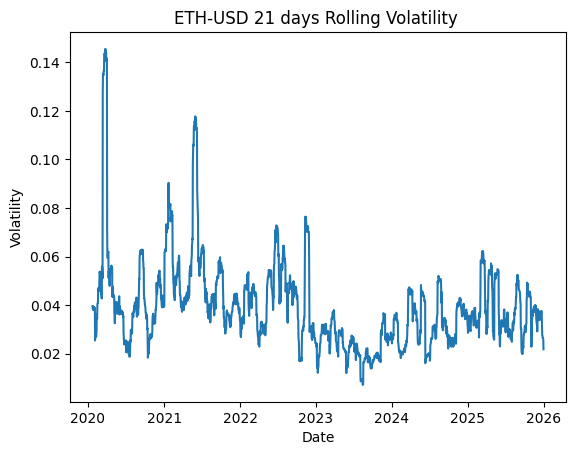

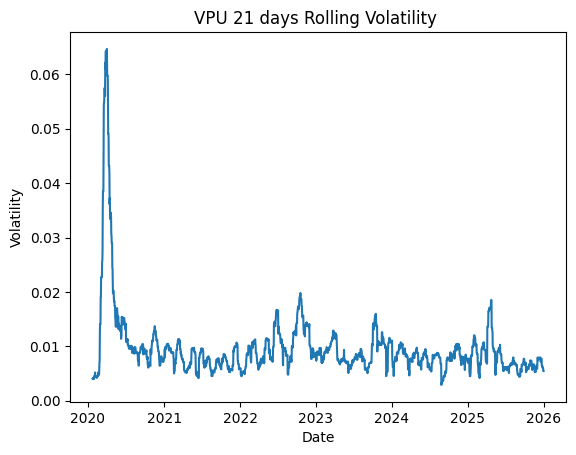

In [8]:
# Daily rolling volatility 21 days window for each asset
roll_volatility=daily_returns.rolling(21).std()

for ticker in tickers:
    if ticker in roll_volatility.columns:
        plt.plot(roll_volatility.index,roll_volatility[ticker])
        plt.title(f"{ticker} 21 days Rolling Volatility ")
        plt.xlabel('Date')
        plt.ylabel('Volatility')
        plt.show()

In [9]:
# Monthly volatility using daily returns
monthly_volati=df_volatility*np.sqrt(21)
monthly_volati

GC=F       0.040938
AAPL       0.076017
NVDA       0.126780
BTC-USD    0.148348
SHY        0.004413
GE         0.091289
TLT        0.040940
ETH-USD    0.198469
VPU        0.053121
dtype: float64

Annual volatility based on Daily Returns and Monthly Returns yields different values. Because in the first one, we are looking at 252 points(252 days), and in the second one, we are looking at 12 points(12 months). So, for example, if a stock goes up 10% in the first two weeks and down 9.09% in the last two weeks, the Daily Volatility will be very high. However, the Monthly Return will be 0%, and the Monthly Volatility calculation won't "see" that mid-month roller coaster.

Another reason is the sample size:

In a small sample of only 12 months, one single "crazy" month (like a 20% drop in ETH-USD) will have a massive, disproportionate impact on your $\sigma$, which is why your ETH-USD jumped from 0.62 (daily) to 0.75 (monthly).

**So, we will take the annual volatility using daily returns when calculating the VaR.**


In [10]:
# Annual volatility using daily returns
annual_volati=df_volatility*np.sqrt(252)
annual_volati

GC=F       0.141813
AAPL       0.263332
NVDA       0.439180
BTC-USD    0.513894
SHY        0.015287
GE         0.316233
TLT        0.141821
ETH-USD    0.687516
VPU        0.184017
dtype: float64

#### 1.4 Correlations (Dependency)

Text(0.5, 1.0, 'Asset correlation matrix')

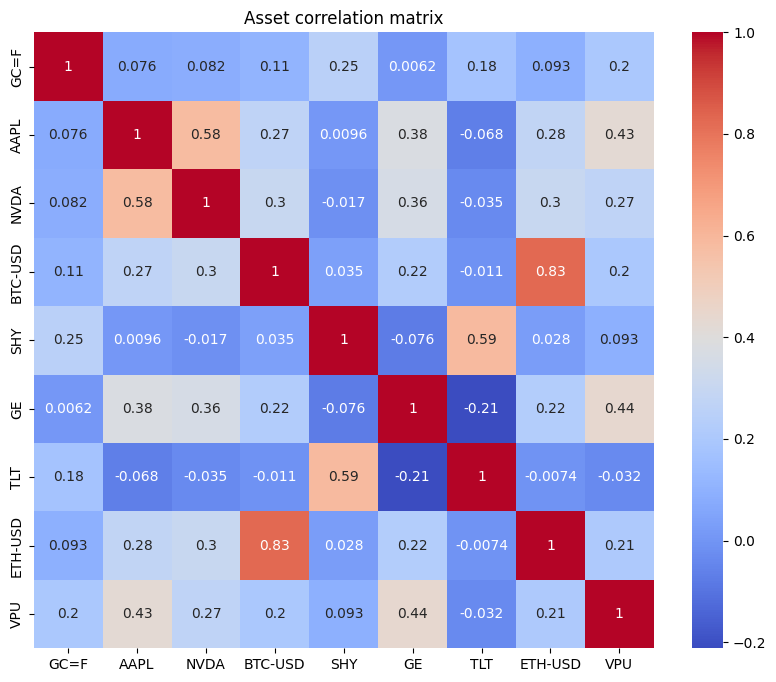

In [11]:
assets_corr=daily_returns.corr('pearson')

plt.figure(figsize=(10,8))
sns.heatmap(assets_corr,annot=True,cmap='coolwarm')
plt.title('Asset correlation matrix')

#### 1.5 Skewness and Kurtosis (Non-Normality)

$X$ (or $x_i$): This is the Random Variable. In our case, it represents the Daily Log Return of a specific asset (like AAPL) for a single day.

$\mu$ (or $\bar{x}$): This is the Mean (Average) of all our returns. It represents the "center" of our distribution.

$(X - \mu)$ or ($x_i$-$\bar{x}$): This is the Deviation. It tells us how far a single day's return "strayed" from the average.

**Skewness**


$$Skewness = \frac{E[(X - \mu)^3]}{\sigma^3}$$

In a sample of $n$ data points, the formula is:

$$s = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{\left[\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2\right]^{3/2}}$$

- Skewness = 0: The distribution is normally distributed.

- Skewness > 0: The distribution has more weight in the right tail.

- Skewness < 0: The distribution has more weight in the left tail.




**Kurtosis**

$$Kurtosis = \frac{E[(X - \mu)^4]}{\sigma^4}$$

In a sample of $n$ data points, the formula is:$$k = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4}{\left[\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2\right]^2}$$

- Mesokurtic Distribution (Kurtosis = 3, Excess Kurtosis = 0): Represents a normal or near-normal distribution.

- Leptokurtic Distribution (Kurtosis > 3, Excess Kurtosis > 0): Has heavier tails than a normal distribution, meaning a **higher chance of extreme values or outliers.** (Eg: A stock has most of the days returns around 1%. And occasionally it gets massive jumps , returns at 10%)

- Platykurtic Distribution (Kurtosis < 3, Excess Kurtosis < 0): Has lighter tails than a normal distribution, meaning fewer extreme values.

In [12]:
# Skewness for each asset
skewness=skew(daily_returns,bias=False)
skewness=pd.DataFrame(skewness,daily_returns.columns)
skewness=skewness.rename(columns={0:'Skewness'})

# Classify according to kurtosis type
skew_conditions=[
    (skewness['Skewness'] > 0),
    (skewness['Skewness'] < 0),
    (skewness['Skewness'] == 0)]
skew_labels=['Right-Tailed (Big gains)','Left-Tailed (Crash Risk)','Normally Distributed']
skewness['Skewness Type']=np.select(skew_conditions,skew_labels)

skewness

,Skewness,Skewness Type
GC=F,-0.417647,Left-Tailed (Crash Risk)
AAPL,0.083926,Right-Tailed (Big gains)
NVDA,0.129673,Right-Tailed (Big gains)
BTC-USD,-1.349918,Left-Tailed (Crash Risk)
SHY,0.905135,Right-Tailed (Big gains)
GE,-0.364130,Left-Tailed (Crash Risk)
TLT,0.088629,Right-Tailed (Big gains)
ETH-USD,-1.064868,Left-Tailed (Crash Risk)
VPU,-0.267853,Left-Tailed (Crash Risk)


In [13]:
# Kurtosis for each asset
kurtosis=kurtosis(daily_returns,bias=False)
kurtosis=pd.DataFrame(kurtosis,daily_returns.columns)
kurtosis=kurtosis.rename(columns={0:'Kurtosis'})

# Classify according to kurtosis type
kurt_conditions=[
    kurtosis['Kurtosis']>3,
    kurtosis['Kurtosis']<3,
    kurtosis['Kurtosis']==3]
kurt_labels=['Leptokurtic (Heavier Tails)','Platykurtic(Lighter Tails)','Mesokurtic (Normal Dist.)']
kurtosis['Kurtosis Type']=np.select(kurt_conditions,kurt_labels)

kurtosis

,Kurtosis,Kurtosis Type
GC=F,6.270071,Leptokurtic (Heavier Tails)
AAPL,10.731009,Leptokurtic (Heavier Tails)
NVDA,7.243744,Leptokurtic (Heavier Tails)
BTC-USD,22.194923,Leptokurtic (Heavier Tails)
SHY,11.733904,Leptokurtic (Heavier Tails)
GE,10.119160,Leptokurtic (Heavier Tails)
TLT,7.572849,Leptokurtic (Heavier Tails)
ETH-USD,15.742802,Leptokurtic (Heavier Tails)
VPU,23.213068,Leptokurtic (Heavier Tails)


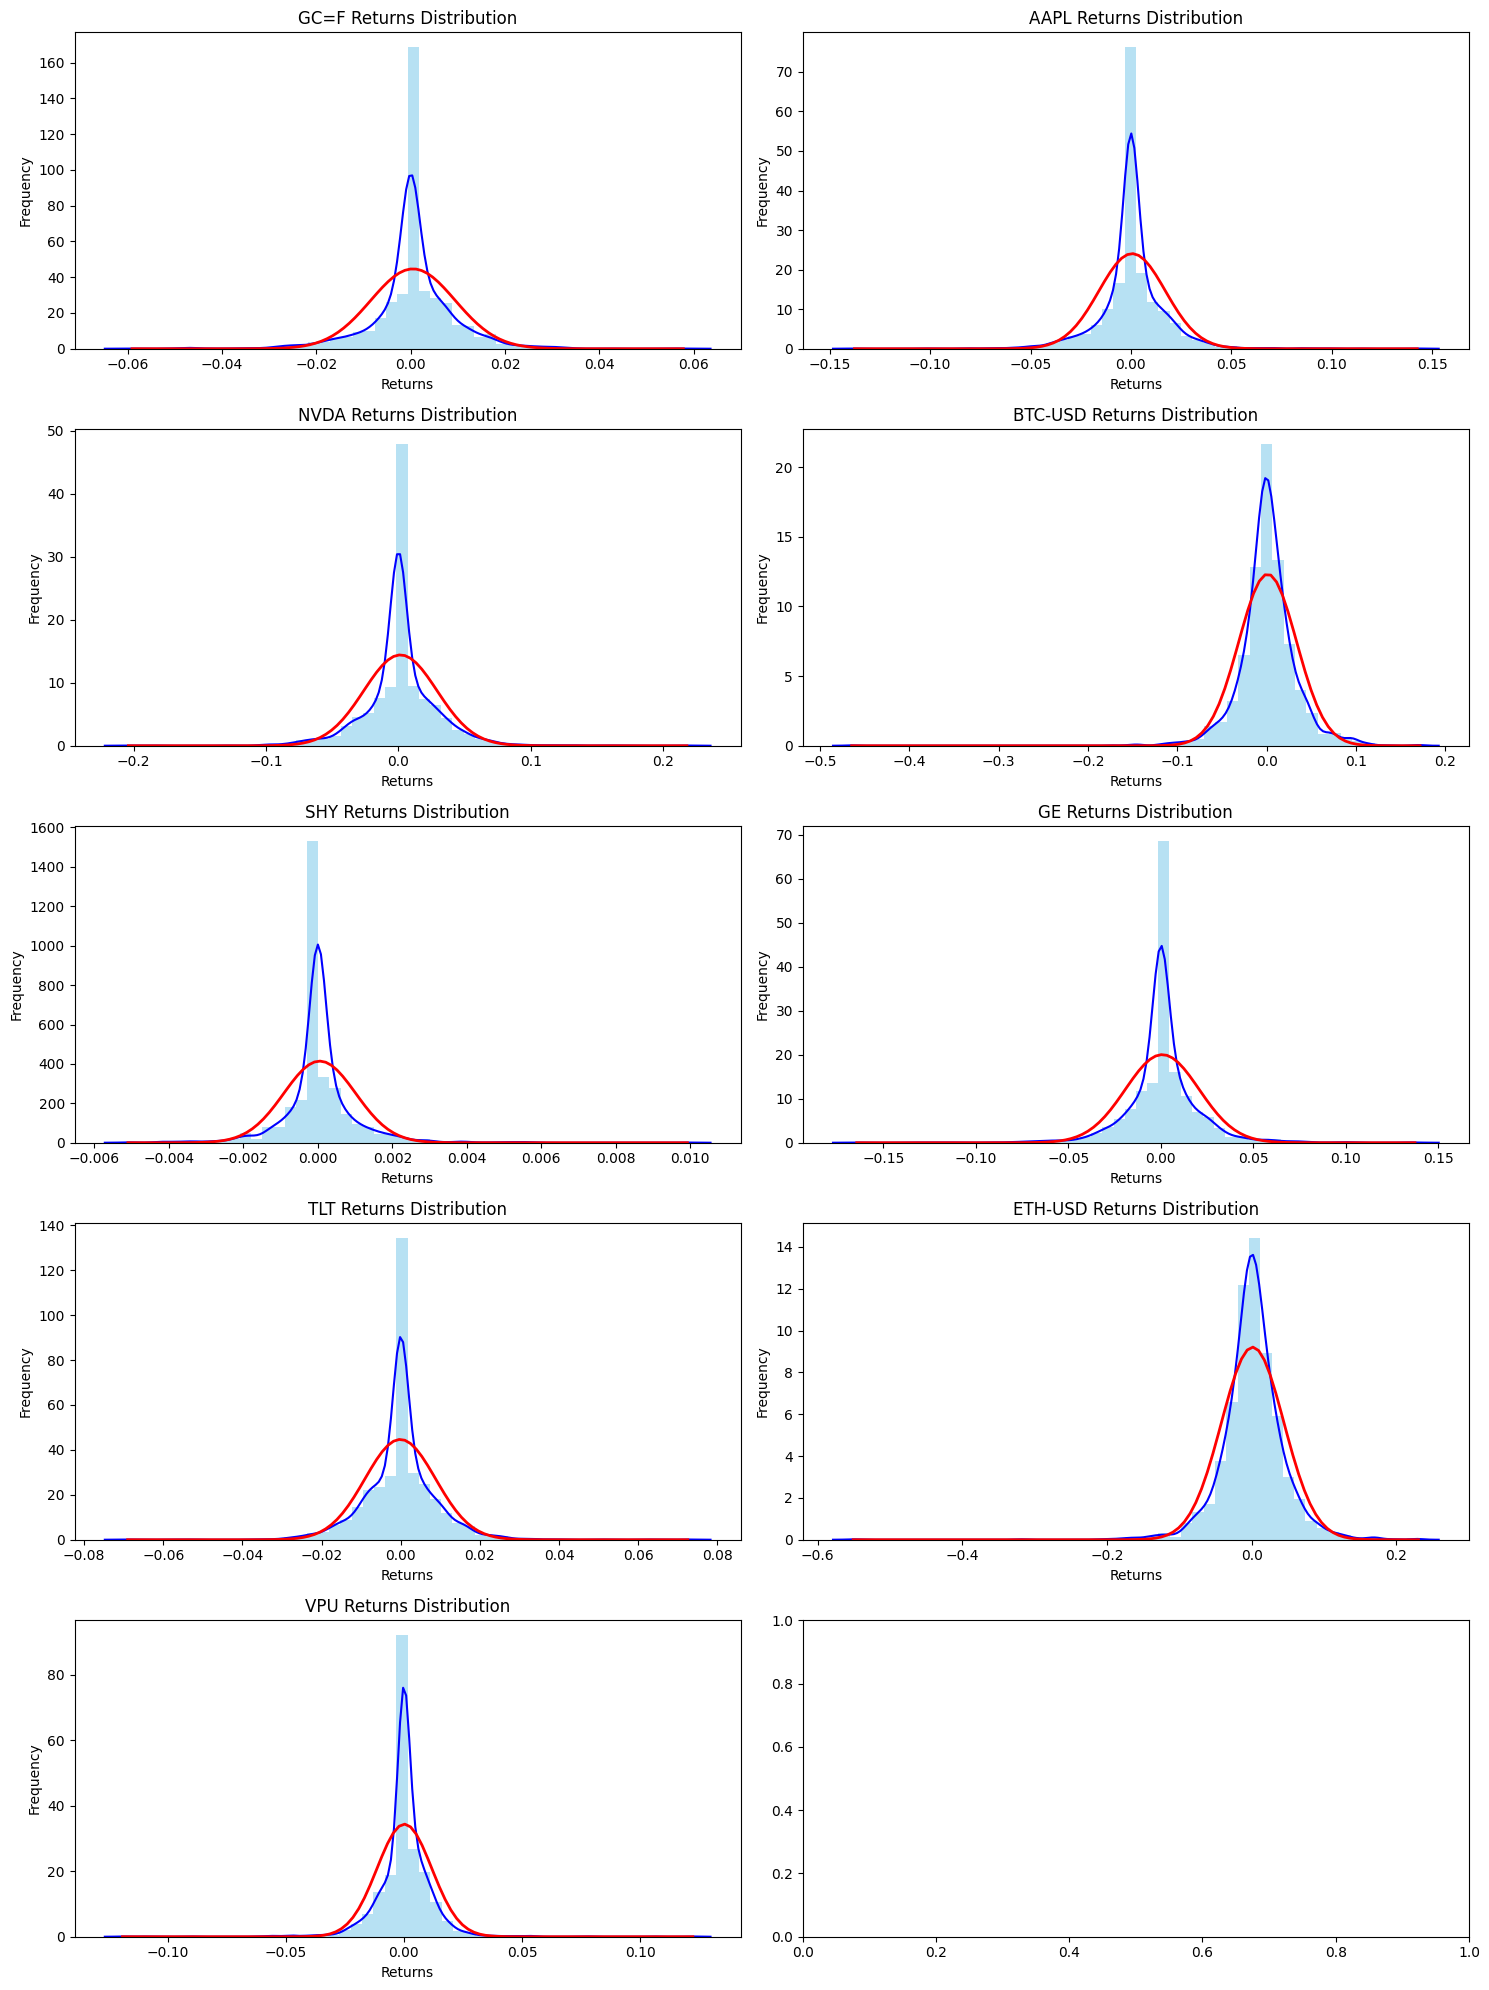

In [14]:
# Visualizing Distributions (histograms) for each asset

# Set up the grid 
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten() # Flatten so we can loop through it easily

for i, ticker in enumerate(tickers): # We use enumerate so each axes matches with each tickers. e.g: axes[0] with GC=F, axes[1] with AAPL, and so on.
    if ticker in daily_returns.columns:
        ax=axes[i] 
        data=daily_returns[ticker].dropna()
        ax.hist(data,bins=50,density=True,alpha=0.6,color='skyblue')
        # Returns distribution line (Kernel line)
        sns.kdeplot(data, ax=ax, color='blue', label='Actual Shape')
        
        ax.set_title(f"{ticker} Returns Distribution")
        ax.set_xlabel('Returns')
        ax.set_ylabel('Frequency')

        # Normal distribution line
        mu,std=stats.norm.fit(data)
        x=np.linspace(data.min(),data.max(),100)
        p=stats.norm.pdf(x,mu,std)
        ax.plot(x,p,'r',linewidth=2,label='Normal Distribution')

plt.tight_layout() # Prevent overlapping

### 2. Building the Porfolio

#### 2.1 Weights (Using Risk Parity)

**Why we use the variance instead of the std for optimization?**

Euler’s Homogeneous Function Theorem. It states that if a function is "homogeneous of degree 2" (like Variance), the sum of the individual contributions multiplied by their weights will exactly equal the total.

$$\sum_{i=1}^n w_i \frac{\partial \sigma_p^2}{\partial w_i} = \sigma_p^2$$

When we divide the contribution by Variance, the results are clean percentages that always sum to 1.0 (100%).
Asset A = 0.50 (50% of risk)
Asset B = 0.50 (50% of risk)
Total = 1.00

If we divide by Standard Deviation, the sum of the parts does not naturally equal 1.0; it equals the total volatility (e.g., 0.127). This makes it harder for a computer to "slice the pie" because the size of the pie changes every time the weights change.



1. **Portfolio variance**: $$\sigma_p^2 = \mathbf{w}^T \mathbf{\Sigma} \mathbf{w}$$

- $\mathbf{w}$ is a column vector of asset weights.

- $\mathbf{w}^T$ is the transpose of that vector (a row vector).

- $\mathbf{\Sigma}$ (Sigma) is the Covariance Matrix.

2. **Risk Contribution ($RC_i$) using Variance**
  $$RC_i = \frac{w_i \cdot (\mathbf{\Sigma} \mathbf{w})_i}{\sigma_p^2}$$


3. **Risk Parity Objective**(calculates the Sum of Squared Errors (SSE). The computer’s goal is to change the weights until this number is as close to 0 as possible)

$$J(\mathbf{w}) = \sum_{i=1}^n (RC_i - \bar{RC})^2$$


In [15]:
# Calculate portfolio variance
def portfolio_variance(weights,cov_matrix):
    return weights.T @ cov_matrix @ weights

def risk_contribution(weights,cov_matrix):
    port_variance=portfolio_variance(weights,cov_matrix)
    marg_contribution=cov_matrix@weights
    risk_contr=(weights*marg_contribution)/port_variance
    return risk_contr

def risk_parity_objective(weights,cov_matrix):
    risk_contrib=risk_contribution(weights,cov_matrix)
    target_risk=np.mean(risk_contrib)
    return np.sum((risk_contrib-target_risk)**2)   

##### 2.1.1 This is Risk Parity but **Unleveraged**


In [16]:
# Optimize the asset weights using the objective function (SSR)

def get_risk_parity_weights(cov_matrix):
    num_assets=len(cov_matrix)
    initial_weights=np.ones(num_assets)/num_assets # It starts with equal weights
    constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) # Ensure weights up to 100% (No leverage)
    bounds=[(0, 1) for _ in range(num_assets)] # Prevent negative weights (you can't go short)

    result=minimize(risk_parity_objective,initial_weights,args=(cov_matrix,),
                   method='SLSQP',bounds=bounds,constraints=constraints)# Sequential Least Squares Programming
    return result.x # The weights I want are in result.x

cov_matrix=daily_returns.cov()
risk_parity_weights=get_risk_parity_weights(cov_matrix)
print("Unleveraged Risk Parity Weights:", risk_parity_weights)

Unleveraged Risk Parity Weights: [0.07500193 0.03199321 0.01969448 0.016389   0.67588597 0.03282951
 0.08935908 0.01223885 0.04660797]


Text(0.5, 0, 'Assets')

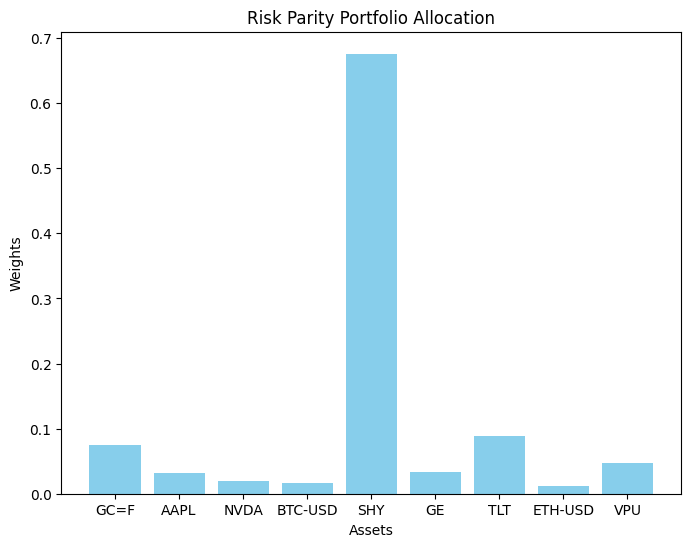

In [17]:
# Visualize portfolio allocation
plt.figure(figsize=(8,6))
plt.bar(tickers,risk_parity_weights,color='skyblue')
plt.title('Risk Parity Portfolio Allocation')
plt.ylabel('Weights')
plt.xlabel('Assets')

#### 2.2 Portfolio metrics

In [18]:
# Evaluate performance(risk parity weights vs equal weights)
risk_parity_returns = pd.Series((np.dot(daily_returns, risk_parity_weights)),index=daily_returns.index)
equal_weighted_returns =pd.Series((np.dot(daily_returns, np.ones(len(tickers)) / len(tickers))),index=daily_returns.index)

In [19]:
# Risk free rate (3-month Treasury Bill)
rf=yf.download("^IRX",start=start_date,end=end_date)['Close']
rf=rf/100

[*********************100%***********************]  1 of 1 completed


In [20]:
def performance_metrics(returns, rf):

    returns = returns.dropna()

    # Align risk-free series and convert annual yield to daily return
    rf_daily = rf.squeeze().reindex(returns.index).ffill() / 252 # squeeze() transform from DataFrame to Series

    cumulative = (1 + returns).cumprod()

    # CAGR
    years = len(returns) / 252
    annual_return = cumulative.iloc[-1]**(1 / years) - 1

    # Annualized volatility
    annual_volatility = returns.std() * np.sqrt(252)

    # Excess daily returns
    excess = returns - rf_daily

    # Sharpe ratio
    sharpe = excess.mean() / excess.std() * np.sqrt(252)

    # Downside deviation
    downside = excess.clip(upper=0)
    downside_std = np.sqrt((downside**2).mean()) * np.sqrt(252)

    # Sortino ratio
    sortino = (
        excess.mean() * 252 / downside_std
        if downside_std > 0 else np.nan
    )

    # Maximum drawdown
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    # Calmar ratio
    calmar = (
        annual_return / abs(max_drawdown)
        if max_drawdown != 0 else np.nan
    )

    return {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown,
        "Sortino Ratio": sortino,
        "Calmar Ratio": calmar,
    }

In [21]:
# Comparasion between both portfolios
rp_metrics = performance_metrics(risk_parity_returns,rf)
ew_metrics = performance_metrics(equal_weighted_returns,rf)

comparison = pd.DataFrame(
    [rp_metrics, ew_metrics],
    index=["Risk Parity", "Equal Weight"]
)

print(comparison.round(4))

              Annual Return  Annual Volatility  Sharpe Ratio  \
Risk Parity          0.0457             0.0441        0.4162   
Equal Weight         0.1665             0.1919        0.7577   

              Maximum Drawdown  Sortino Ratio  Calmar Ratio  
Risk Parity            -0.1485         0.5835        0.3079  
Equal Weight           -0.4303         1.0403        0.3870  


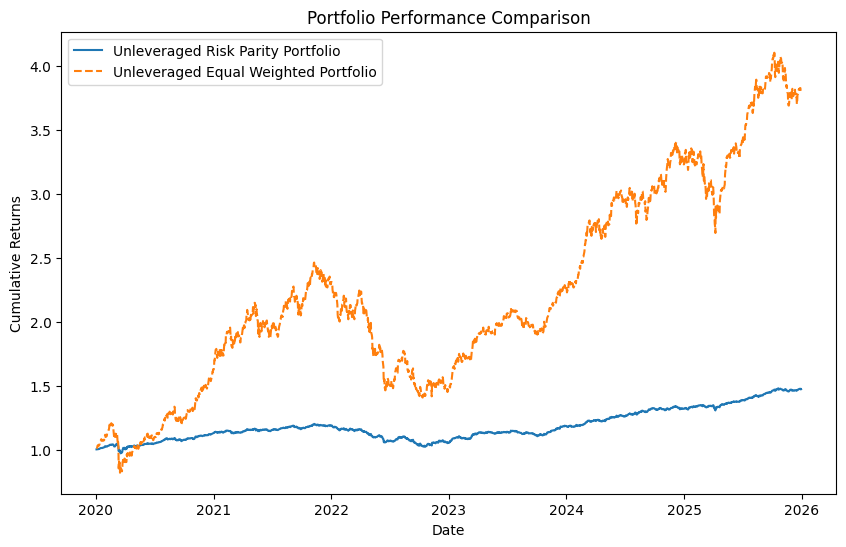

In [22]:
# Portfolio performance
plt.figure(figsize=(10, 6))
plt.plot((1 + risk_parity_returns).cumprod(), label='Unleveraged Risk Parity Portfolio')
plt.plot((1 + equal_weighted_returns).cumprod(), label='Unleveraged Equal Weighted Portfolio', linestyle='--')
plt.title('Portfolio Performance Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

### 3. VaR (Value at Risk)

#### 3.1 Parametric VaR (Variance-Covariance VaR) (normal curve)

The logic behind Parametric VaR is that data follows a normal distribution.


**Advantages:**

- **Simplicity and Speed**: It is computationally very fast. Since it only requires the mean and standard deviation of returns, you don't need to process thousands of historical data points or run complex simulations.

- **Ease of Interpretation**: Because it relies on the standard Normal Distribution, the results are easy to explain to stakeholders using familiar concepts like Z-scores and confidence intervals.

- **Less Data Required**: Unlike Historical VaR, which needs years of clean data to be reliable, the Parametric method can be calculated with relatively short time series as long as the volatility estimate is stable.

**Drawbacks:**

- **The "Normality" Assumption:** It assumes market returns follow a symmetric bell curve. In reality, markets often have Negative Skewness and Fat Tails (Kurtosis), meaning this method frequently underestimates the risk of extreme crashes.

- **The "Linear" Flaw**: It struggle with non-linear assets like Options or convertible bonds. Since the delta (sensitivity) of an option changes as the price moves, a simple linear standard deviation cannot capture the true risk.

- **Constant Volatility Myth**: It assumes that volatility is stable over the measured period. But volatility depends on historical volatility (GARCH models), volatility actually "clusters," meaning Parametric VaR can be dangerously inaccurate during periods of market stress.


- For the portfolio:
  $$VaR_{portfolio} = Initial\_Investment \times (\mu_p - Z_{\alpha} \sigma_p)$$

- For individual stock:
    $$VaR_{stock} = Initial\_Investment \times (\mu_{stock} - Z_{\alpha} \sigma_{stock})$$

- VaR percentage:

  $$VaR_{percentage} = \mu - (abs(Z) \times \sigma)$$
  

When reporting the VaR figure we can add absolute to make it positive.

##### 3.1.1 For each asset

In [23]:
initial_invest=1000000
individual_investments=initial_invest*risk_parity_weights
conf_level=0.95
port_returns=risk_parity_returns
stock_returns_mean=daily_returns.mean()
stock_std=np.std(daily_returns)
z_score=abs(norm.ppf(1-conf_level)) # This is abs(-1.645)=1.645

In [24]:
VaR_parametric=individual_investments*(stock_returns_mean-z_score*stock_std)
VaR_parametric

GC=F      -1066.000688
AAPL       -853.558024
NVDA       -865.205540
BTC-USD    -853.670986
SHY       -1036.479935
GE        -1050.451877
TLT       -1324.270836
ETH-USD    -854.258806
VPU        -878.784332
dtype: float64

In [25]:
VaR_parametric.sum()

-8782.681024049032

In [26]:
VaR_parametric_percentage=stock_returns_mean-z_score*stock_std
print('There is a 5% chance that each individual asset lose more than \n ',abs(round(VaR_parametric_percentage,4))*100)

There is a 5% chance that each individual asset lose more than 
  GC=F       1.42
AAPL       2.67
NVDA       4.39
BTC-USD    5.21
SHY        0.15
GE         3.20
TLT        1.48
ETH-USD    6.98
VPU        1.89
dtype: float64


##### 3.1.2 For the portfolio

In [27]:
port_returns_mean=port_returns.mean()
port_std=np.sqrt(portfolio_variance(risk_parity_weights,cov_matrix))

In [28]:
VaR_parametric_port=initial_invest*(port_returns_mean-z_score*port_std)
VaR_parametric_port

-4386.398389086356

In [29]:
VaR_parametric_port_percentage=(port_returns_mean-(z_score*port_std))
print('There is a 5% chance that the portfolio lose more than ',abs(round(VaR_parametric_port_percentage,3))*100,"%")

There is a 5% chance that the portfolio lose more than  0.4 %


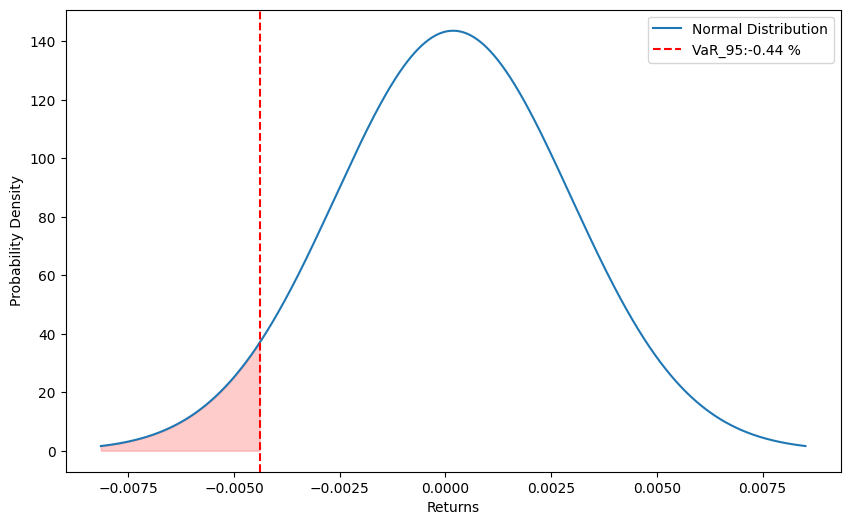

In [30]:
# Plot normal distribution and VaR threshold for the portfolio
plt.figure(figsize=(10,6))
x=np.linspace(port_returns_mean-3*port_std,+port_returns_mean+3*port_std,1000)
y=norm.pdf(x,port_returns_mean,port_std)
plt.plot(x,y,label='Normal Distribution')

# VaR threshold
plt.axvline(VaR_parametric_port_percentage,color='red',linestyle='--',label=f'VaR_95:{round(VaR_parametric_port_percentage*100,2)} %')
plt.fill_between(x,0,y,where=(x<=VaR_parametric_port_percentage),color='red',alpha=0.2)
plt.xlabel('Returns')
plt.ylabel('Probability Density')
plt.legend()

#### 3.2 Modified VaR (MVaR) or Cornish-Fisher (non-normal curve)

If our distribution is not normal, but the deviations from normality are ‘small’,we can approximate our non-normal distribution using the Cornish–Fisher expansion, which tells us how to adjust the standard normal variate αcl to accommodate non-normal skewness and kurtosis. When using the Cornish–Fisher approximation, we should keep in mind that **it will only provide a ‘good’ approximation if our distribution is ‘close’ to being normal**, and we cannot expect it to be much use if we have a distribution that is too non-normal.

We can if there are close or far away from a normal distribution looking at their kurtosis. If their kurtosis is between 3 and 5 , then they have a small deviation from normality because the kurtosis of a normal distribution is 3. And the skewness of the normal dist is 0.

**Advantages:**

- **Captures "Fat Tails"**: Unlike the normal distribution, it accounts for the fact that extreme events (Kurtosis) happen more often in finance than a bell curve predicts.

- **Accounts for Asymmetry**: If an asset like BTC has negative skewness (crashes harder than it climbs), Cornish-Fisher will increase the VaR to reflect that "crash" risk.

- **Computational Efficiency**: It gives you "Non-Normal" accuracy without needing the massive historical datasets or heavy simulations (like Monte Carlo) required by other methods.


**Drawbacks:**

- **The "Domain" Problem:** If your Skewness or Kurtosis values are too extreme, the formula can "break" and become non-monotonic (it might say your 99% VaR is lower than your 95% VaR, which is impossible).

- **Sensitivity to Outliers:** Because it relies on the 3rd and 4th moments (Skew/Kurtosis), a single massive outlier in your data can wildly swing your VaR estimate.

- **Model Complexity:** It is significantly harder to explain to a non-technical client than a simple Historical VaR or a standard Gaussian VaR.



The formula is:

$$\tilde{Z}_{\alpha} = Z_{\alpha} + \frac{1}{6}(Z_{\alpha}^2 - 1)S + \frac{1}{24}(Z_{\alpha}^3 - 3Z_{\alpha})K - \frac{1}{36}(2Z_{\alpha}^3 - 5Z_{\alpha})S^2$$

Where:

- $Z_{\alpha}$ = The standard normal critical value (e.g., $-1.645$ for 95% VaR).
- $S$ = Skewness of the returns.
- $K$ = Excess Kurtosis of the returns.

The final VaR is:

$$\text{VaR portfolio} = \text{Portfolio Value} \times (\mu_{p} + \tilde{Z}_{\alpha} \times \sigma_{p})$$


In [31]:
# Check the kurtosis returns
print('Portfolio Skewness:',stats.skew(port_returns,bias=False),'\nPortfolio Kurtosis:',stats.kurtosis(port_returns,bias=False))


Portfolio Skewness: -0.628970929882063 
Portfolio Kurtosis: 14.136774800640694


In [32]:
# In this case, we shouldn't use the MVaR because the portfolio returns are not close to a normal dist.
def MVaR(returns,conf_level,initial_invest):
    z_score=norm.ppf(1-conf_level) 
    s=stats.skew(returns,bias=False)
    k=stats.kurtosis(returns,bias=False)
    new_z_score=z_score+1/6*(z_score**2-1)*s+1/24*(z_score**3-3*z_score)*k-1/36*(2*z_score**3-5*z_score)*s**2
    mvar=returns.mean()+new_z_score*returns.std()
    mvar_dollar=abs(initial_invest*mvar)

    return mvar*100,mvar_dollar

mvar_results=abs(round(pd.DataFrame(MVaR(port_returns,conf_level,initial_invest),index=['MVaR_%','MVaR_$']),3)).T
mvar_results

,MVaR_%,MVaR_$
0,0.407,4070.018


#### 3.3 Historical VaR (no curve)

Having strong assumptions, such as a normal distribution, might be the cause of inaccurate estimations. A solution to this issue is the historical simulation VaR. This is an empirical method: instead of using a parametric approach, we **find the percentile**, which is the Z-table equivalent of variance-covariance method.


**Advantages:**

- **No Distribution Assumptions**: It doesn't care about "Bell Curves," Mean, or Z-scores. It naturally captures Skewness and Fat Tails (Kurtosis) because it uses actual market data where those "Black Swans" already happened.

- **Handles Non-Linear Assets**: It works well for portfolios with Options. Since you are re-pricing your options based on actual past price moves, it captures the complex way option values change (Greeks) without needing a PhD in calculus.

- **Intuitive and "Audit-Friendly"**: It is very easy to explain to a board of directors. You can say: "In the worst 5 days out of the last 100, we lost at least $X." It feels more "grounded" than a theoretical formula.


**Drawbacks:**

- **The "Window" Problem:** It is entirely dependent on your data set (and requires a large sample). If your 2-year window doesn't include a crash (like 2008 or 2020), your VaR will be dangerously low. It assumes the future will look exactly like the past.

- **The "Ghost Effect":** When a massive one-day crash happens, it stays in your VaR calculation for exactly as long as your window (e.g., 250 days). The day it "drops out" of the window, your VaR will suddenly plummet, even if the market is still risky.

- **Static Weighting:** It treats a crash that happened 2 years ago with the same "importance" as a market move that happened yesterday.Historical VaR often fails to react quickly to a sudden spike in today's volatility.

- **Highly computationally expensive**

The process for calculating the Historical VaR:

1. **Collect and Calculate Returns**: Gather the historical prices for your portfolio over a specific window (e.g., the last 100 days). Calculate the daily percentage return for each day:$$r_t = \ln(P_t) - \ln(P_{t-1})$$

2. **Sort the Returns:** Arrange all your calculated returns in a list from worst to best (lowest to highest).Example: If your worst five days were $-5\%, -4.2\%, -3.9\%, -3.1\%,$ and $-2.5\%$, they go at the very top of your list.

3. **Determine the "Rank" ($n$)**. Decide on your Confidence Level (usually 95% or 99%). Use this formula to find which position in your sorted list represents the VaR:$$n = (1 - \text{Confidence Level}) \times \text{Total Number of Observations}$$If you have 120 days of data and want 95% VaR: $n = (1 - 0.95) \times 120 = 6$. Interpretation: Your VaR is the 6th worst return in your sorted list. (so, the 6th worst day corresponds to the percentile 5)

4. **Convert to Portfolio Value:** Since $r = \ln(P_{new}/P_{old})$, the drop in value is calculated as:$$\text{VaR (\%)} = 1 - e^{r^*}$$If your log return rank was $-0.0315$, your VaR is $1 - e^{-0.0315} \approx 3.1\%$.

##### 3.2.1 For each asset

In [33]:
individual_investments_serie=pd.Series(individual_investments,index=tickers)

VaR_historical_results={}
for ticker in tickers:
    log_VaR_historical=np.percentile(daily_returns[ticker],(1-conf_level)*100)  # Here we multiply by 100 because np.percentile requires a percentile between 0 and 100

    arithmetic_VaR_historical=1-np.exp(log_VaR_historical)
    
    ticker_investment=individual_investments_serie[ticker]
    dollar_VaR=ticker_investment*arithmetic_VaR_historical
    
    VaR_historical_results[ticker]={
        'VaR_%':round(arithmetic_VaR_historical*100,2),
        'VaR_$':round(dollar_VaR,2)}
    

VaR_historical_results_df=pd.DataFrame(VaR_historical_results).T[['VaR_%','VaR_$']]
VaR_historical_results_df

,VaR_%,VaR_$
GC=F,1.47,1098.95
AAPL,2.57,822.22
NVDA,4.10,808.05
BTC-USD,4.68,766.45
SHY,0.13,888.74
GE,2.87,942.63
TLT,1.47,1314.21
ETH-USD,6.31,772.18
VPU,1.65,767.17


##### 3.2.2 For the portfolio

In [34]:
log_VaR_historical_port=np.percentile(port_returns,(1-conf_level)*100)# Here we multiply by 100 because np.percentile requires a percentile between 0 and 100
VaR_historical_port=1-np.exp(log_VaR_historical_port)
print('The portfolio Historical VaR is',round(VaR_historical_port,3), 'or' ,round(VaR_historical_port*100,1), '%')
print('They portfolio Historical VaR ($) is' ,round(initial_invest* VaR_historical_port,3), "$")

The portfolio Historical VaR is 0.004 or 0.4 %
They portfolio Historical VaR ($) is 3964.325 $


In [35]:
# Calculate undiversified VaR 
undiversified_VaR=VaR_historical_results_df['VaR_$'].sum()
print('Undiversified is',undiversified_VaR,'$')
print('They portfolio Historical VaR ($) is' ,round(initial_invest* VaR_historical_port,3), "$")
print('Diversification benefit is ', undiversified_VaR-round(initial_invest* VaR_historical_port,3),'$')

Undiversified is 8180.6 $
They portfolio Historical VaR ($) is 3964.325 $
Diversification benefit is  4216.275000000001 $


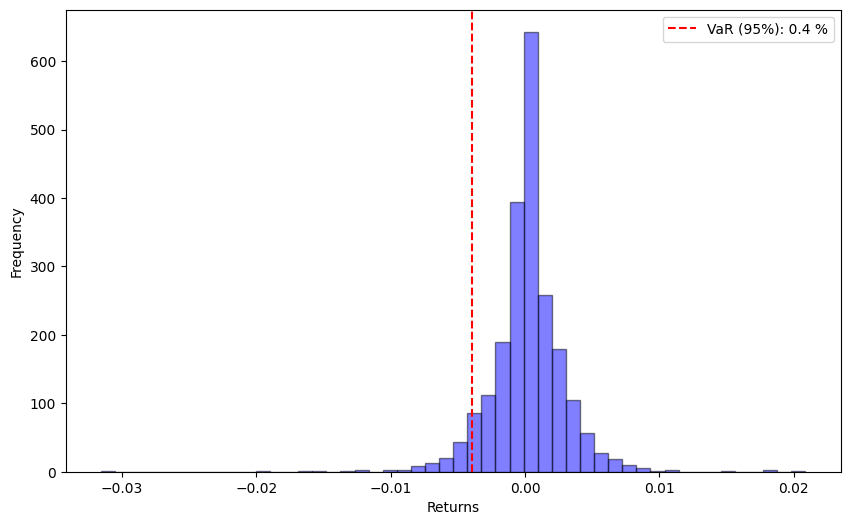

In [36]:
plt.figure(figsize=(10,6))
plt.hist(port_returns,bins=50,alpha=0.5,color='blue',edgecolor='black')
plt.axvline(-VaR_historical_port,color='red',linestyle='--',label=f'VaR (95%): {round(VaR_historical_port*100,1)} %')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()

#### 3.4 Monte Carlo VaR (simulated curve)

This method uses random sampling to simulate a range of potential outcomes based on historical data.It uses a computer to simulate 10,000+ versions of what could happen based on the assets' volatility and correlations.

**Advantages**:

- **Flexibility with "Non-Linear" Assets**: If your portfolio contains Options or complex derivatives, their value doesn't move in a straight line with the market. Monte Carlo is the only method that accurately captures how these assets behave when prices swing wildly.

- **Custom Risk "Scenarios":** Unlike Historical VaR, you aren't stuck with the past. You can "stress test" the simulation by telling the computer: "Simulate 10,000 days, but assume inflation stays at 5% and oil prices double." It allows for "What-If" analysis.

- **Captures Path Dependency:** Monte Carlo can account for events that depend on the order of prices (like a "barrier option" that expires if a price is touched at any point during the month), which simple formulas cannot see.


**Drawbacks**:

- **"Garbage In, Garbage Out" (Model Risk):** The simulation is only as good as the parameters you give it. If you tell the computer that NVDA has a volatility of 20% but it actually hits 80%, your entire VaR calculation will be dangerously wrong.

- **Computational Intensity:** While Historical VaR takes milliseconds, a complex Monte Carlo simulation for a large portfolio can take minutes or even hours to run. This makes "real-time" risk monitoring difficult.

- **False Sense of Security**: Because it produces a clean, high-tech distribution curve based on 100,000 trials, users often trust it blindly. However, it still struggles to predict "Black Swan" events that aren't programmed into the underlying distribution model.

For a standard portfolio, we use Geometric Brownian Motion (GBM) to simulate the 'random walk' of prices. Because the idea of Monte Carlo is simulate a stochatic process not solving a single equation.

1. Calculate the asset price (Use GBM):

$$S_{t+1} = S_t \cdot e^{(\mu - \frac{1}{2}\sigma^2)\Delta t + \sigma\epsilon\sqrt{\Delta t}}$$

- ($S_{t+1}$):the price of an asset at the end of tomorrow
- $S_t$: Current Portfolio Value (e.g., $10,000).
  
- $\mu$: Expected daily return (mean).
  
- $\sigma$: Daily volatility (standard deviation).
  
- $\epsilon$: The Random Variable. A random number pulled from a standard normal distribution
  
- $N(0,1)$.
  
- $\Delta t$: Time step (for 1 day, $\Delta t = 1$).


2. Calculate the simulated returns:

$$R_i = \frac{S_{i, t+1} - S_t}{S_t}$$

3. Sort simulated returns from worst to best, and find the percentile.
N=nº of simulations

$$\text{VaR Rank} = N \times (1 - \text{Confidence Level})$$


**THIS IS THE MOST IMPORTANT, AND WE USE IT TO CALCULATE THE VAR FOR THE PORTFOLIO USING THE MONTE CARLO METHOD**

**The "Portfolio" Twist (Cholesky Decomposition)**: When doing this for a portfolio (like yours with BTC, NVDA, SHY, etc.), you can't just pull random numbers for each stock independently. You have to make sure that if the "market" crashes in your simulation, correlated stocks crash together.

To do this by hand, you multiply your random vector by the Cholesky Decomposition of your covariance matrix:

$$\text{Correlated Randoms} = L \cdot \epsilon$$

Where $L$ is the lower-triangular matrix such that $L \cdot L^T = \text{Covariance Matrix}$

$\epsilon$ is my random vector with simulated returns (epsilon is a matrix with 10 rows and 10000 columns )

In [37]:
# Create a function to calculate Monte Carlo VaR

def monte_carlo_var(returns,conf_level,initial_invest,n_simulations=10000):
    mu=returns.mean()
    cov_matrix=returns.cov()
    # random.multivariate_normal (generate 100000 scenarios for all 10 assets simultaneously, and take into account the Cholesky decomposition)
    simulated_daily_returns=np.random.multivariate_normal(mu,cov_matrix,n_simulations)
    weights=get_risk_parity_weights(cov_matrix)
    portfolio_sim_returns=np.dot(simulated_daily_returns,weights)

    var_MC_percentile=np.percentile(portfolio_sim_returns,(1-conf_level)*100)
    var_MC_dollar=initial_invest*var_MC_percentile

    return var_MC_percentile,var_MC_dollar,portfolio_sim_returns

mc_var_results=round(pd.DataFrame(monte_carlo_var(daily_returns,conf_level,initial_invest),index=['MC_VaR','MC_VaR_$','Portfolio_simulate_returns']),3).T
mc_var_results['MC_VaR_%']=mc_var_results['MC_VaR']*100
mc_var_results['MC_VaR_$']=abs(mc_var_results['MC_VaR_$'])
mc_var_results

,MC_VaR,MC_VaR_$,Portfolio_simulate_returns,MC_VaR_%
0,-0.004319,4319.368746,"[0.0035751174646868646, -0.002631084658611694,...",-0.431937


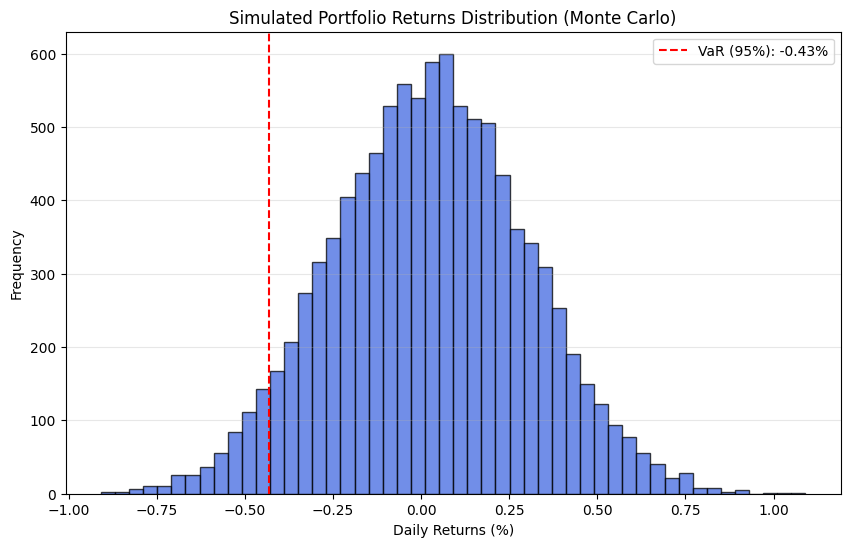

In [38]:
plt.figure(figsize=(10, 6))

# 1. Extract the actual data array from the DataFrame
# We use .iloc[0] because your transposed DataFrame stores the list in the first row
sim_data = mc_var_results['Portfolio_simulate_returns'].iloc[0]

# 2. Extract the specific VaR percentage value as a single number
var_val = mc_var_results['MC_VaR_%'].iloc[0]

# 3. Plot the histogram using the extracted array
plt.hist(sim_data*100, bins=50, alpha=0.75, color='royalblue', edgecolor='black')

# 4. Draw the vertical line using the single float value
plt.axvline(x=var_val, color='red', linestyle='--', 
            label=f'VaR (95%): {var_val:.2f}%')

plt.title('Simulated Portfolio Returns Distribution (Monte Carlo)')
plt.xlabel('Daily Returns (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### VaR Summary

In [39]:
# 1. Collect all your results into a dictionary.

comparison_data = {
    'VaR %': [
        abs(VaR_parametric_port_percentage * 100), 
        abs(VaR_historical_port * 100),           
        abs(mvar_results['MVaR_%'].iloc[0]),       
        abs(mc_var_results['MC_VaR_%'].iloc[0])    
    ],
    'VaR $': [
        abs(VaR_parametric_port),                 
        round(initial_invest * VaR_historical_port, 3), 
        abs(mvar_results['MVaR_$'].iloc[0]),       
        abs(mc_var_results['MC_VaR_$'].iloc[0])    
    ]
}

# 2. Define the row labels
row_labels = ['Parametric VaR', 'Historical VaR', 'Modified VaR', 'Monte Carlo VaR']

# 3. Create the DataFrame
df_comparison = pd.DataFrame(comparison_data, index=row_labels)

# 4. Final Formatting: Round to 3 decimal places
df_comparison = df_comparison.round(3)

# Display the table
print(df_comparison)

                 VaR %     VaR $
Parametric VaR   0.439  4386.398
Historical VaR   0.396  3964.325
Modified VaR     0.407  4070.018
Monte Carlo VaR  0.432  4319.369


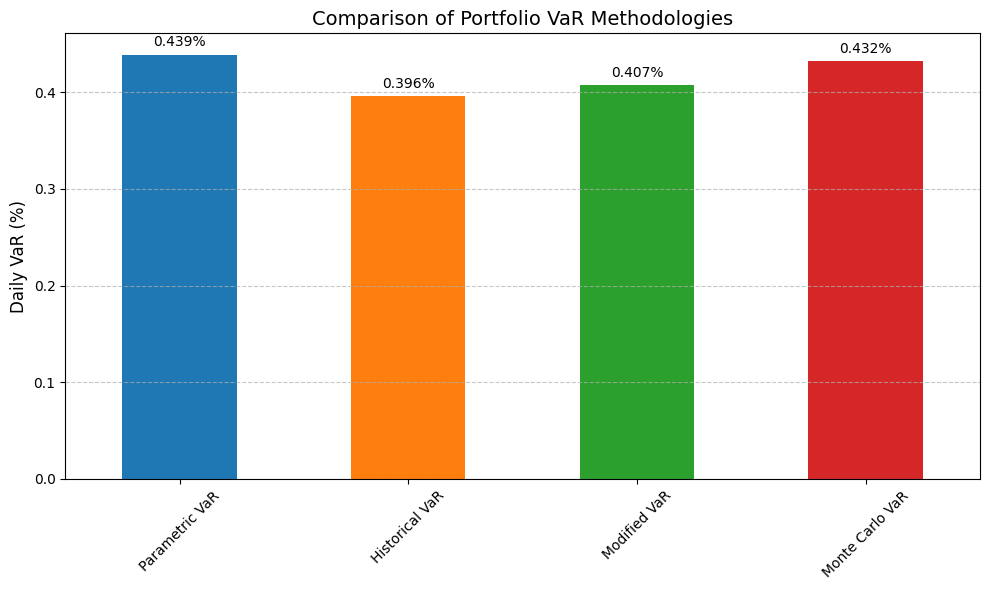

In [40]:
# Plotting the comparison
ax = df_comparison['VaR %'].plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

plt.title('Comparison of Portfolio VaR Methodologies', fontsize=14)
plt.ylabel('Daily VaR (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the values on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

### 4.Expected Shortfall(ES) or ETL(Expected Tail Loss) or Conditional VaR (CVaR) or Average Value at Risk (AVaR)

The **Expected Shortfall** tells us what we can expect to **lose if a tail event does occur**.

**Advantages**:
- **Captures Tail Risk:** VaR only tells you the minimum loss you can expect on a bad day. It doesn't distinguish between a 5% loss and a 50% loss if both are past the threshold. ES calculates the average of all losses in that tail.
- **Subadditive (Diversification benefit)**: This is a mathematical property where the ES of a combined portfolio is always less than or equal to the sum of the ES of individual assets ($ES(A+B) \le ES(A) + ES(B)$). However, VaR is not subadditive.
- **Convexity**: the sub-additivity of Expected Shortfall implies that the portfolio risk surface will be convex. This convexity ensures that portfolio
optimisation problems with Expected Shortfall risk measures can be handled very efficiently using linear programming techniques.

**Drawbacks**:

- **Hard to Backtest**: It is very easy to check if VaR was wrong (you just count how many times you lost more than the VaR). It is mathematically much harder to prove that your ES "average loss" was accurate after the fact.
- **Data Sensitivity (Sample Risk)**: Because ES focuses on the very tip of the tail (the worst 1% or 5% of days), it relies on very few data points. If you only have 250 days of data, a 95% ES is based on only 12 or 13 days. One single massive outlier (like a COVID-19 crash) can wildly swing your ES result, making it "noisier" and less stable than VaR.
- **Complexity in Communication**: Regulators and boards of directors understand VaR intuitively: "There is a 5% chance we lose more than $X. Explaining ES ("The expected value of the loss, given that the loss has exceeded the VaR threshold") often requires more mental gymnastics for non-technical stakeholders.


Formula:

$$ES_{\alpha} = \frac{1}{1-\alpha} \int_{\alpha}^{1} VaR_{u} \, du$$

In other words,

**ES = Average of all losses that are worse than your VaR.**


#### 4.1 ES using Monte Carlo VaR

In [41]:
# Using Monte Carlo VaR
port_sim_returns=mc_var_results['Portfolio_simulate_returns'].iloc[0]
tail_loss=port_sim_returns[port_sim_returns<mc_var_results['MC_VaR'].iloc[0]]
expect_shortfall=tail_loss.mean()
expect_shortall_results=pd.DataFrame([expect_shortfall,abs(expect_shortfall*100),abs(expect_shortfall*initial_invest)],index=['ES','ES_%','ES_$']).T
expect_shortall_results

,ES,ES_%,ES_$
0,-0.005391,0.539112,5391.119202


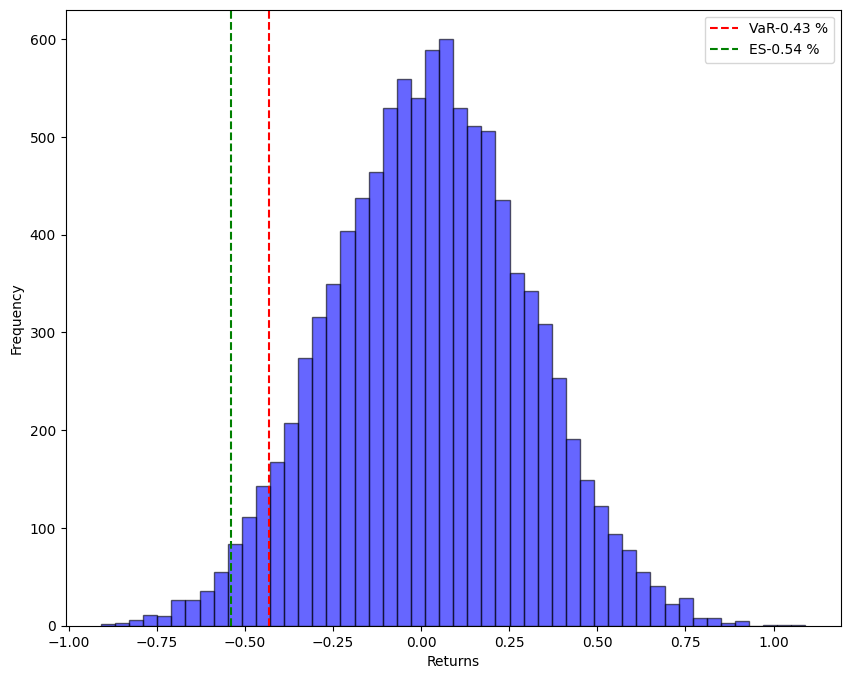

In [42]:
plt.figure(figsize=(10,8))
plt.hist(sim_data*100,bins=50,alpha=0.6,color='blue',edgecolor='black')
var_value = mc_var_results['MC_VaR'].iloc[0]
expect_shortall_value=expect_shortall_results['ES'].iloc[0]
plt.axvline(x=var_value*100,color='red',linestyle='--',label=f'VaR{round(var_value*100,2)} %')
plt.axvline(x=expect_shortall_value*100,color='green',linestyle='--',label=f'ES{round(expect_shortall_value*100,2)} %')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()

### 5. Incremental VaR (IVaR) and Component VaR (CVaR)

Risk addition and decomposition is how changing our portfolio alters our risk, and how we can decompose our portfolio risk into constituent or component risk.

- **Incremental riks**: These are the changes in risk when some factor changes. For example, we might want to know how VaR changes when we add a new position to our portfolio, and in this case the incremental VaR or IVaR is the change in VaR associated with the addition of the new position to our portfolio.

- **Component risks:** These are the component or constituent risks that make up a certain total risk.For instance, if we have a portfolio made up of particular positions, the portfolio VaR can be broken down into components, known as component VaRs or CVaRs, that tell us how much each position contributes to the overall portfolio VaR.


**IVaR** gives us an indication of how those risks change when we change the portfolio itself. Three cases:

- **High positive IVaR:** An asset has a High IVaR if it significantly increases the portfolio's total risk. The cause is : High volatility combined with high positive correlation with the rest of your portfolio.
- **Moderate IVaR**: Most assets in a diversified portfolio fall here. They add some risk, but not a disproportionate amount. The asset’s risk is partially offset by its lack of perfect correlation with the other holdings.
- **Negative IVaR**: Means that adding more of this asset actually decreases your total Portfolio VaR.The asset has a negative correlation with the existing portfolio.

#### 5.1 Incremetal VaR (IVaR)

**Incremental VaR (IVaR)**:

There are two methods to calculate it:

1. **Difference method:**

$$IVaR_{i} = VaR_{p+i} - VaR_{p}$$ 

$$IVaR_i = \text{Portfolio VaR} - \text{VaR without Asset } i$$

Where:

- $VaR_{p+i}$ is the VaR of the portfolio including the new asset (or the increased position).

- $VaR_{p}$ is the VaR of the original portfolio.


In [43]:
# Difference method

# Get the 10000 simulated returns for all 10 assets (We need the individual asset simulations, not just the total)
mu=daily_returns.mean()
cov = daily_returns.cov()
sim_assets = np.random.multivariate_normal(mu, cov, 10000)
weights = get_risk_parity_weights(cov)

# Baseline VaR (Full portfolio)
baseline_returns=sim_assets@weights
baseline_var=np.percentile(baseline_returns,(1-conf_level)*100)

# Calculate the difference
ivar_diff={}

for i,col in enumerate(daily_returns.columns): # i--> index position, col-->the name
    w_new=weights.copy() # I don't want to accidentally change my actual portfolio weights during the loop.
    w_new[i]=0 # Remove asset i
    w_new=w_new/np.sum(w_new) # Re-scale to weights=1 because we just deleted the weight from the asset i

    # Calculate New VaR
    new_var=np.percentile(sim_assets@w_new,(1-conf_level)*100)

    # Difference
    ivar_diff[col]=baseline_var-new_var

df_ivar_diff=pd.Series(ivar_diff)
df_ivar_diff

GC=F       0.000036
AAPL      -0.000258
NVDA      -0.000312
BTC-USD   -0.000289
SHY        0.007817
GE        -0.000188
TLT        0.000096
ETH-USD   -0.000309
VPU       -0.000148
dtype: float64

By what percentage did your Portfolio Volatility drop compared to just holding the most volatile asset (ETH-USD)?

In [45]:
portfolio_vol = baseline_returns.std()
eth_vol = daily_returns['ETH-USD'].std()
discount = (1 - (portfolio_vol / eth_vol)) * 100
print(f"Diversification Discount: {discount:.2f}%")

Diversification Discount: 93.59%


#### 5.2 Marginal VaR

**Marginal effect:**
How VaR change when you increase or decrease an asset position size (weight)?

It says that the change in VaR is roughly the Marginal VaR times the change in weight.

$$IVaR_{i} \approx \frac{\partial VaR}{\partial w_i} \times \Delta w_i$$

$$IVaR_i \approx \text{Weight}_i \times \text{Average return of Asset } i \text{ during VaR days}$$

In [46]:
# Marginal Effect (Calculating Ivar using this method you are using ivar_marginal=component vaR)

# 1. Identify "VaR Days" (days where portfolio return <= baseline_var)
is_var_day = baseline_returns <= baseline_var # Compare only returns that are in the tail

# 2. Calculate average return for each asset ONLY on those bad days
marginal_var = sim_assets[is_var_day].mean(axis=0)

# 3. Multiply by weight to get the Marginal Effect IVaR
ivar_marginal = marginal_var * weights

df_ivar_marginal = pd.Series(ivar_marginal, index=daily_returns.columns)
df_ivar_marginal

GC=F      -0.000607
AAPL      -0.000612
NVDA      -0.000648
BTC-USD   -0.000618
SHY       -0.000645
GE        -0.000601
TLT       -0.000652
ETH-USD   -0.000586
VPU       -0.000620
dtype: float64

In [47]:
# Comparison of both methods

ivar_final = pd.DataFrame({
    'Difference (Exact)': df_ivar_diff,
    'Marginal (Estimate)': df_ivar_marginal
})

# Sort by the biggest risk injectors
print(ivar_final.sort_values(by='Difference (Exact)', ascending=False))

         Difference (Exact)  Marginal (Estimate)
SHY                0.007817            -0.000645
TLT                0.000096            -0.000652
GC=F               0.000036            -0.000607
VPU               -0.000148            -0.000620
GE                -0.000188            -0.000601
AAPL              -0.000258            -0.000612
BTC-USD           -0.000289            -0.000618
ETH-USD           -0.000309            -0.000586
NVDA              -0.000312            -0.000648


In [48]:
# 1. Find the position (index) of the assets in your columns
gold_idx = daily_returns.columns.get_loc('GC=F')
nvda_idx = daily_returns.columns.get_loc('NVDA')

# 2. Divide the IVaR by the actual weight at that position
# This gives you the "Pure" average return on the 500 worst days
marginal_return_gold = -0.000544 / weights[gold_idx]
marginal_return_nvda = -0.000339 / weights[nvda_idx]

print(f"Gold average return on bad days: {marginal_return_gold:.4%}")
print(f"NVDA average return on bad days: {marginal_return_nvda:.4%}")

Gold average return on bad days: -0.7253%
NVDA average return on bad days: -1.7213%


 e.g : GC=F       Difference(Structural diversification)--> 0.000036   and  Marginal (Crisis movement)--->  -0.000544

Difference: 0.000036--> So, the var decrease with gold in the portfolio, because it has inverse correlation and lower volatility than btc,eth,nbis , the portfolio is safer with gold than without it.

Marginal: -0.000544 ---> During a crash, the gold also loss money, but slower than other asset like nvda or btc.

Here: 

GC=F               0.000036            -0.000544
NVDA              -0.000190            -0.000339

The gold has a higher number because it has a higher weights. But see the cell above to understand it.

For Gold (GC=F), we see a divergence in risk metrics. The Marginal Estimate (-0.000544) shows that Gold tends to co-move with the portfolio during extreme tail events. However, the Difference Method (+0.000036) proves Gold’s value as a stabilizer; removing it and re-allocating to higher-volatility assets would result in a net increase in total portfolio risk."


#### 5.3 Component VaR (CVaR)

Key points:

- **The "Slice of the Pie":** Component VaR measures the exact amount of risk that a specific asset contributes to the total portfolio VaR.

- **The Magic of Additivity:** Because of Euler's Theorem, if you add up the Component VaR of every single asset in your portfolio, it will perfectly equal your Total Portfolio VaR.

- **Risk Budgeting:** Portfolio managers use this to see if their Risk Allocation matches their Capital Allocation. (e.g., "I only put 5% of my money in Crypto, but Component VaR shows it's taking up 40% of my risk budget!").

$$CVaR_i = w_i \times \frac{\partial VaR_p}{\partial w_i}$$

(Where $w_i$ is the weight of the asset, and the derivative is the Marginal VaR).

In [49]:
# 1. Calculate the Total Portfolio Returns
portfolio_returns = sim_assets @ weights

# 2. Find the Total Portfolio VaR (95% Confidence)
conf_level = 0.05
total_var = np.percentile(portfolio_returns, conf_level * 100)

# 3. Isolate the "Tail Days" (<= total_var calculates Expected Shortfall)
is_var_day = (portfolio_returns <= total_var)

# 4. Calculate the Marginal Expected Shortfall 
marginal_es = sim_assets[is_var_day].mean(axis=0)

# 5. Calculate COMPONENT Expected Shortfall
component_es = marginal_es * weights

# 6. Calculate Total Expected Shortfall (Sum of Components)
total_es = component_es.sum() 

# Print the difference between the Borderline (VaR) and the Tail Average (ES)
print(f"Total Portfolio VaR (Borderline): {total_var:.6f}")
print(f"Total Portfolio Expected Shortfall (Tail Average): {total_es:.6f}\n")

# 7. Build the clean DataFrame
df_risk_decomp = pd.DataFrame({
    'Ticker': daily_returns.columns,  # Maps back to GC=F, NVDA, etc.
    'Weight': weights,
    'Component ES': component_es,   
    '% Contribution': (component_es / total_es) * 100  # Perfect 100% split
})

# 8. Set the Ticker as the index and sort it
df_risk_decomp = df_risk_decomp.set_index('Ticker').sort_values(by='% Contribution', ascending=False)

# 9. Print the final results
print(f"Sum of % Contribution: {df_risk_decomp['% Contribution'].sum():.0f}%\n")
print("Corrected Risk Decomposition:")
print(df_risk_decomp)

Total Portfolio VaR (Borderline): -0.004295
Total Portfolio Expected Shortfall (Tail Average): -0.005588

Sum of % Contribution: 100%

Corrected Risk Decomposition:
           Weight  Component ES  % Contribution
Ticker                                         
TLT      0.089359     -0.000652       11.674600
NVDA     0.019694     -0.000648       11.603331
SHY      0.675886     -0.000645       11.534797
VPU      0.046608     -0.000620       11.094159
BTC-USD  0.016389     -0.000618       11.058507
AAPL     0.031993     -0.000612       10.944498
GC=F     0.075002     -0.000607       10.853126
GE       0.032830     -0.000601       10.750574
ETH-USD  0.012239     -0.000586       10.486409


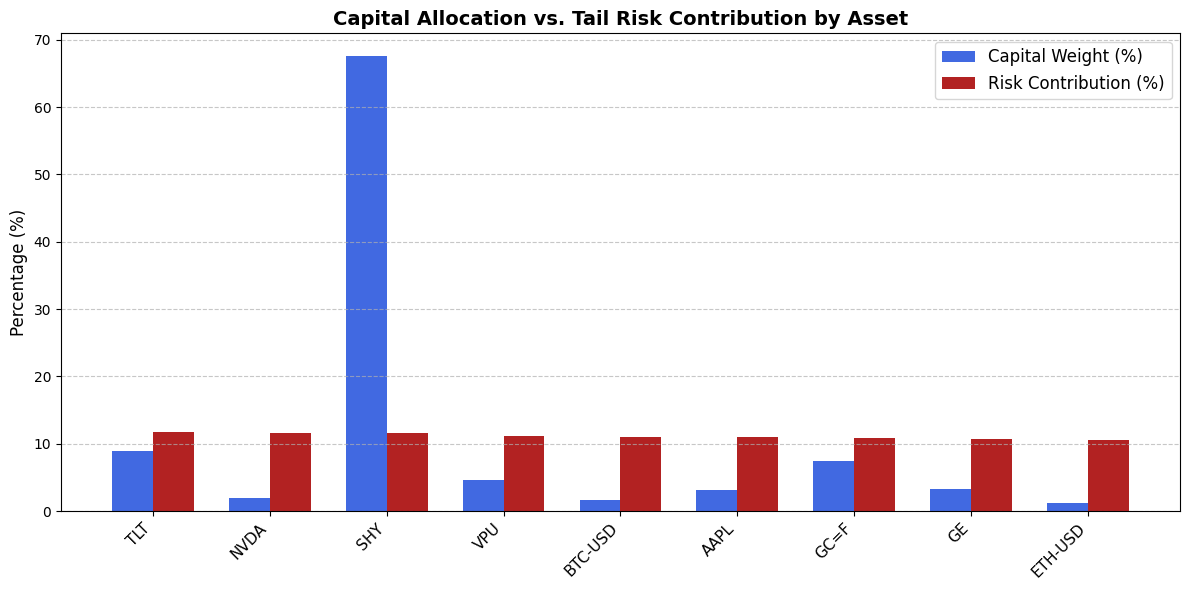

In [50]:
# 1. Prepare the data (Convert decimal Weight to Percentage for fair comparison)
tickers = df_risk_decomp.index
weight_pct = df_risk_decomp['Weight'] * 100
risk_pct = df_risk_decomp['% Contribution']

# 2. Set up the bar locations
x = np.arange(len(tickers))  # The label locations
width = 0.35                 # The width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, weight_pct, width, label='Capital Weight (%)', color='royalblue')
rects2 = ax.bar(x + width/2, risk_pct, width, label='Risk Contribution (%)', color='firebrick')

# 4. Add text, titles, and custom axes
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Capital Allocation vs. Tail Risk Contribution by Asset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12)

# 5. Add a grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# 6. Make it look clean
fig.tight_layout()

### 6. Backtesting 

There are three main backtesting methologies:
- **Coverage test:** Assess whether the frequency of exceedances is consistent with the quantile of loss a value-at-risk measure is intended to reflect.
- **Distribution test:** Assess goodness-of-fit tests applied to the overall loss distributions forecast by complete value-at-risk measures.(e.g: QQ-plots)
- **Independence test:** Assess whether results appear to be independent from one period to the next.

#### 6.1 The Kupiec Test

In [51]:
# 1. Prepare a table for backtest ,so take portfolio returns
backtest_df=pd.DataFrame(port_returns).rename(columns={0:'Portfolio_returns'})
backtest_df

,Portfolio_returns
Date,
2020-01-03,0.004078
2020-01-04,0.000228
2020-01-05,0.000110
2020-01-06,0.002436
2020-01-07,0.000298
...,...
2025-12-26,0.001035
2025-12-27,0.000186
2025-12-28,0.000009


In [52]:
# 1.1 If we calculate P&L in dollars
backtest_df['P&L']=backtest_df['Portfolio_returns']*initial_invest

In [53]:
# 2. Build a rolling Monte Carlo VaR series (a VaR for each day for the first 250 days)
window=250
initial_invest=1000000
conf_level=0.95
n_simulations=10000
var_forecast=[]

dates=daily_returns.index

for i in range(window,len(daily_returns)):
    estimation_window=daily_returns.iloc[i-window:i]

    var_MC_percentile,var_MC_dollar,_=monte_carlo_var(returns=estimation_window,conf_level=conf_level,initial_invest=initial_invest,n_simulations=n_simulations)
    var_forecast.append({
        'Dates':dates[i],
        'Var_MC':var_MC_percentile,
        'VaR_MC_$':var_MC_dollar
    })

var_df=pd.DataFrame(var_forecast).set_index('Dates')
var_df

,Var_MC,VaR_MC_$
Dates,,
2020-09-09,-0.027724,-27723.879385
2020-09-10,-0.027950,-27949.649852
2020-09-11,-0.027919,-27918.971359
2020-09-12,-0.027978,-27978.424899
2020-09-13,-0.028182,-28182.049710
...,...,...
2025-12-26,-0.002632,-2631.893971
2025-12-27,-0.002735,-2735.081804
2025-12-28,-0.002717,-2717.040767


In [54]:
# 3. Join both backtest_df and var_df (inner join) We use join because they have 'date' as a index
backtest_df=backtest_df.join(var_df,how='inner')

In [55]:
backtest_df

,Portfolio_returns,P&L,Var_MC,VaR_MC_$
2020-09-09,0.004139,4138.597884,-0.027724,-27723.879385
2020-09-10,-0.001849,-1849.451052,-0.027950,-27949.649852
2020-09-11,-0.000863,-863.462801,-0.027919,-27918.971359
2020-09-12,0.000466,466.115247,-0.027978,-27978.424899
2020-09-13,-0.000890,-889.912871,-0.028182,-28182.049710
...,...,...,...,...
2025-12-26,0.001035,1034.666010,-0.002632,-2631.893971
2025-12-27,0.000186,186.466506,-0.002735,-2735.081804
2025-12-28,0.000009,8.650828,-0.002717,-2717.040767
2025-12-29,-0.003435,-3434.637425,-0.002633,-2632.736601


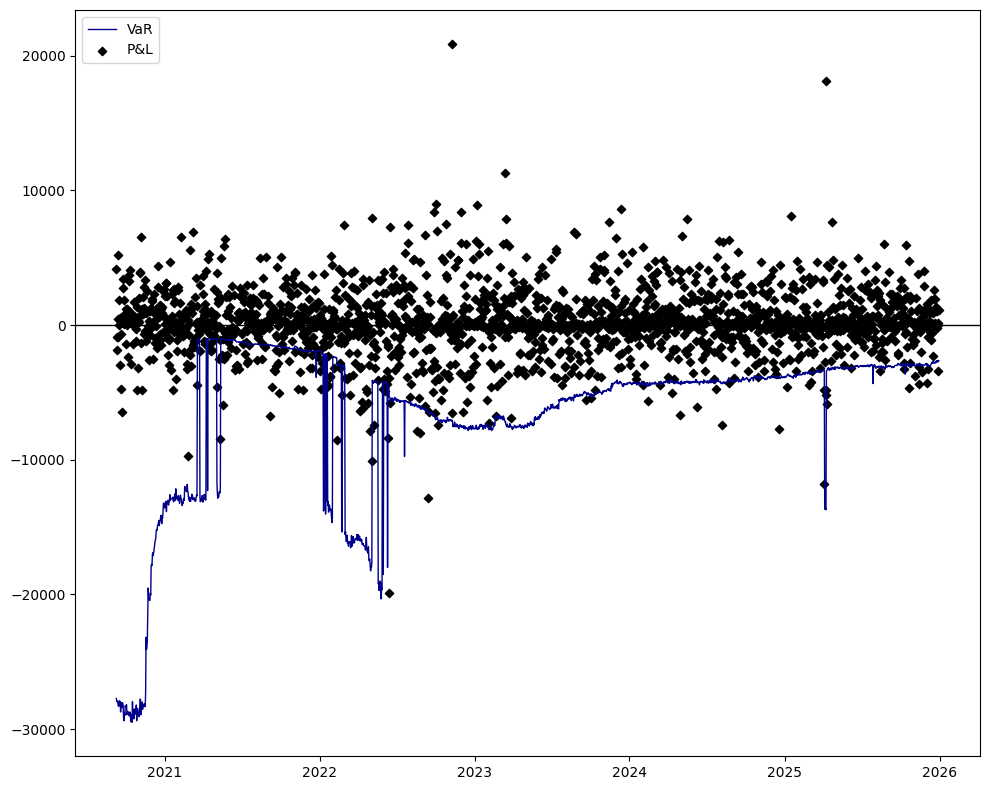

In [56]:
# Plot backtesting
# These VaR spikes are because of nbis and eth volatility when simulating monte carlo prices cuz there cov matrix

plt.figure(figsize=(10,8))
plt.plot(backtest_df.index,backtest_df['VaR_MC_$'],color='darkblue',linewidth=1,label='VaR')
plt.scatter(backtest_df.index,backtest_df['P&L'],color='black',s=18,marker='D',label='P&L')
plt.axhline(0,color='black',linewidth=1)
plt.legend(loc='upper left')
plt.tight_layout()

In [57]:
# 3. Exception indicator (Compare port returns to VaR)
backtest_df['exception']=(backtest_df['Portfolio_returns']<backtest_df['Var_MC']).astype(int)

In [58]:
backtest_df

,Portfolio_returns,P&L,Var_MC,VaR_MC_$,exception
2020-09-09,0.004139,4138.597884,-0.027724,-27723.879385,0
2020-09-10,-0.001849,-1849.451052,-0.027950,-27949.649852,0
2020-09-11,-0.000863,-863.462801,-0.027919,-27918.971359,0
2020-09-12,0.000466,466.115247,-0.027978,-27978.424899,0
2020-09-13,-0.000890,-889.912871,-0.028182,-28182.049710,0
...,...,...,...,...,...
2025-12-26,0.001035,1034.666010,-0.002632,-2631.893971,0
2025-12-27,0.000186,186.466506,-0.002735,-2735.081804,0
2025-12-28,0.000009,8.650828,-0.002717,-2717.040767,0
2025-12-29,-0.003435,-3434.637425,-0.002633,-2632.736601,1


In [59]:
# 4. Count exceptions (negative exceptions)
n_exceptions=backtest_df['exception'].sum()
n_observations=len(backtest_df)
exception_rate=n_exceptions/n_observations

if exception_rate>0.05:
    print(round(exception_rate,3),'too many exceptions, so risk underestimated')
else:
    print(round(exception_rate,3),'Consevative')

0.05 Consevative


In [60]:
# 5. Calculate Prob(X>n_exceptions) to check if there is too many negative exceptions (This is one-sided test) Is the model too risky?
# H0: good model--> exception rate= p    p=0.05
# H1: not good model--> exception rate > p    p=0.05


# For a VaR95%, significance level is 0.05
sign_level=0.05
tail_prob=1-binom.cdf(n_exceptions,n_observations,sign_level)
if tail_prob>=0.05:
    print('Good model') 
else:
    print('Not good model')

Good model


In [61]:
# 6. Kupieck test (This is two-sided test)  We test two many or too few exceptions . Is a correct model?
# H0: good model--> exception rate= p    p=0.05
# H1: not good model--> exception rate != p    p=0.05

x = n_exceptions
n = n_observations
p = 0.05
p_hat=exception_rate
sig_level = 0.05

lr_uc = -2 * (
    (n - x) * np.log((1 - p) / (1 - p_hat)) +
    x * np.log(p / p_hat)
)

p_value = 1 - chi2.cdf(lr_uc, df=1)

print("Kupiec LR statistic:", lr_uc)
print("Kupiec p-value:", p_value)

if p_value < sig_level:
    print("Not good model")
else:
    print("Good model")

Kupiec LR statistic: 0.009829336667396271
Kupiec p-value: 0.9210247223011441
Good model


**Confidence Intervals** (Normal approx.)

$$\hat{p}± z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [62]:
# 7. Calculate Confidence Intervals
z=norm.ppf(0.975)
p_hat=exception_rate
n = n_observations
p=0.05 # theoretical exception rate (because VaR is 95%)

se=np.sqrt((p_hat*(1-p_hat))/n)
ci_lower=p_hat-z*se
ci_upper=p_hat+z*se

print('95% CI for execption rate: [',round(ci_lower,3),';',round(ci_upper,3),']')

if ci_lower<=p<=ci_upper:
    print('Model acceptable: expected rate lies within the confidence interval')
else:
    print('Model not acceptable: expected rate lies outside the confidence interval')


95% CI for execption rate: [ 0.04 ; 0.059 ]
Model acceptable: expected rate lies within the confidence interval


In [63]:
# CI for the number of exceptions
ci_count_lower=ci_lower*n
ci_count_upper=ci_upper*n
print('95% CI for execption rate: [',round(ci_count_lower,1),';',round(ci_count_upper,1),']')

expected_exceptions = round(p * n,1)
print("Expected number of exceptions:", expected_exceptions)

if ci_count_lower <= expected_exceptions <= ci_count_upper:
    print("Model acceptable.")
else:
    print("Model not acceptable.")

95% CI for execption rate: [ 77.3 ; 114.7 ]
Expected number of exceptions: 97.0
Model acceptable.


**Basel traffic light**

Important: **These areas only apply to VaR 99% one day model, and we need at least 250 trading days, and a 250 days window**. For other confidence levels , they don't apply.

The multiplier $M$ is determined by $K$ (the number of negative exceptions over the last 250 trading days using VaR 99% one-day).$$M = \begin{cases} 3 & \text{if } K \leq 4 \quad \text{(Green)} \\ 3 + 0.2(K - 4) & \text{if } 5 \leq K \leq 9 \quad \text{(Yellow)} \\ 4 & \text{if } K \geq 10 \quad \text{(Red)} \end{cases}$$

**Basel capital requirement:**

Basel capital requirement Formula: The capital a bank must hold as a capital requirement is the maximum value between the weighted 60-day average and the most recent day's risk measure.General Formula:$$\text{Basel capital requirement} = \max \left\{ M \times \text{Avg last 60 days VaR}; \text{yesterday VaR} \right\}$$Mathematical Notation:$$\max \left\{ M \times \frac{1}{60} \sum_{i=1}^{60} \text{VaR}_{t-i}; \text{VaR}_{t-1} \right\}
$$

Example :
60 days Avg ES/VaR = 2 million

Multiplier ($M$) = 3.5 (This implies $K=6.5$ or a specific regulatory penalty)

Yesterday VaR = 6 million

Calculate the weighted average: $3.5 \times 2 = \mathbf{7 \text{ million}}$

Compare with yesterday's VaR: $6 \text{ million}$

Apply the $\max$ function: $\max \{7; 6\} = \mathbf{7}$

Result: 7 million as a capital requirement.

In [64]:
# Count exceptions over the most recent 250 days
window=250
recent=backtest_df.tail(window).copy()

n_exceptions=int(recent['exception'].sum())
n_obs=len(recent)

print('Observations',n_obs)
print('Negative exceptions',n_exceptions)

Observations 250
Negative exceptions 11


In [65]:
# Basel traffic light function (I need at least 250 observations)
def basel_traffic_light(n_exceptions:int,n_obs:int=250)->str: # -> str The output will be a string
    if n_obs !=250:
        raise ValueError('Classic Basel traffic light thresholds 0-4 / 5-9 / 10+ are for 250 observations.')
    if n_exceptions <=4:
        zone='green'
        interpretation='Model performance is acceptable'
        multiplier=3
    elif n_exceptions<=9:
        zone='yellow'
        interpretation='Model performance is questionable; supervisory attention.'
        multiplier=3+0.2*(n_exceptions-4)
    else:
        zone= 'red'
        interpretation='Model performance is poor; strong supervisory concern'
        multiplier=4

    return zone, interpretation,multiplier

zone, interpretation,multiplier =basel_traffic_light(6,250) # We should use n_exceptions,n_obs as inputs (and n_obs has to be greater than 250)
print(' Zone:',zone,'\n','Interpretation :', interpretation,'\n','Multiplier',multiplier)

 Zone: yellow 
 Interpretation : Model performance is questionable; supervisory attention. 
 Multiplier 3.4


In [66]:
# Basel capital 
backtest_df['var_avg_60_days']=backtest_df['VaR_MC_$'].rolling(60).mean() 
backtest_df['basel_component_1']=multiplier*backtest_df['var_avg_60_days']
backtest_df['basel_component_2']=backtest_df['VaR_MC_$'].shift(1)
backtest_df['capital_requirement']=pd.concat([backtest_df['basel_component_1'],backtest_df['basel_component_2']],axis=1).max(axis=1)

current_capital_requirement=abs(backtest_df['capital_requirement'].iloc[-1]) # It has to be positive for regulatory purposes
print('The capital requirement is : ',round(current_capital_requirement,3),'$')

The capital requirement is :  2632.737 $


#### 6.2 Independence Test ( Christoffersen test)

It is usually split into:

**Unconditional coverage test**: Checks whether the number of exceptions is correct.

**Independence test**: Checks whether exceptions are independent over time, rather than clustered.

**Conditional coverage test:** Combines the first two.


Intuition.

A good VaR model should produce exceptions at the right frequency with no clustering.

Example for 95% VaR:

expected exception probability is 5%

over many days, about 5% of days should be exceptions

those exceptions should not arrive in bunches like: 0 0 0 1 1 1 0 0 1 1

because clustering suggests volatility dynamics are not well captured.


**Unconditional coverage test**:

For 95% VaR:

𝑝 =0.05

Observed exception probability:$$\hat{p} = \frac{x}{T}$$

Hypotheses$H_0: \hat{p} = p$$H_1: \hat{p} \neq p$

LikelihoodsUnder the null:$$L_0 = (1-p)^{T-x} p^x$$

Under the alternative:$$L_1 = (1-\hat{p})^{T-x} \hat{p}^x$$

Test statistic$$LR_{uc} = -2 \ln\left(\frac{L_0}{L_1}\right)$$

This is asymptotically distributed as:$$\chi^2(1)$$  If $LR_{uc} > \chi^2(1)$, reject $H_0$




**Independence test**: It checks whether exceptions are serially independent.The idea is to model the hit sequence as a 2-state Markov chain.

We count transitions:$n_{00}$: 0 followed by 0$n_{01}$: 0 followed by 1$n_{10}$: 1 followed by 0$n_{11}$: 1 followed by 1Example hit sequence: $[0,0,1,0,1,1,0]$Transitions are: $0 \to 0, 0 \to 1, 1 \to 0, 0 \to 1, 1 \to 1, 1 \to 0$ 

So:

$n_{00} = 1$ 
$n_{01} = 2 $ 
$n_{10} = 2  $ 
$n_{11} = 1$


Null hypothesis Under independence, the probability of exception does not depend on yesterday’s outcome:$$H_0: \pi_{01} = \pi_{11} = \pi$$Where:$$\pi_{01} = \frac{n_{01}}{n_{00}+n_{01}}$$$$\pi_{11} = \frac{n_{11}}{n_{10}+n_{11}}$$Pooled probability:$$\pi = \frac{n_{01}+n_{11}}{n_{00}+n_{01}+n_{10}+n_{11}}$$

Likelihood under null$$L_0 = (1-\pi)^{n_{00}+n_{10}} \pi^{n_{01}+n_{11}}$$Likelihood under alternative$$L_1 = (1-\pi_{01})^{n_{00}} \pi_{01}^{n_{01}} (1-\pi_{11})^{n_{10}} \pi_{11}^{n_{11}}$$Test statistic$$LR_{ind} = -2 \ln\left(\frac{L_0}{L_1}\right)$$

This is asymptotically:$$\chi^2(1)$$  If $LR_{ind} > \chi^2(1)$, reject $H_0$.


**Conditional coverage test:** This combines both ideas: Correct exception frequency + Independence

$H_0$: correct coverage and independence

Statistic$$LR_{cc} = LR_{uc} + LR_{ind}$$This follows:$$\chi^2(2)$$  

If $LR_{cc} > \chi^2(2)$, reject $H_0$

It uses 2 degree of freedom because combine two tests


In [67]:
def christoffersen_test(exceptions, alpha=sig_level):
    """
    Christoffersen VaR backtesting tests.

    Parameters
    ----------
    exceptions : array-like
        Binary array where:
        1 = VaR exception
        0 = no exception
    alpha : float
        Expected exception probability.
        Example:
        alpha = 0.05 for 95% VaR
        alpha = 0.01 for 99% VaR

    Returns
    -------
    dict
        Dictionary with test statistics and p-values:
        - LR_uc: unconditional coverage statistic
        - p_uc: p-value for unconditional coverage
        - LR_ind: independence statistic
        - p_ind: p-value for independence
        - LR_cc: conditional coverage statistic
        - p_cc: p-value for conditional coverage
        - counts: transition counts
        - observed_failure_rate: empirical exception rate
    """

    exceptions = np.asarray(exceptions).astype(int)

    if not np.all(np.isin(exceptions, [0, 1])):
        raise ValueError("exceptions must contain only 0 and 1")

    T = len(exceptions)
    if T < 2:
        raise ValueError("Need at least 2 observations")

    # -------------------------
    # 1) Unconditional coverage
    # -------------------------
    x = exceptions.sum()
    p_hat = x / T

    # Avoid log(0) problems
    eps = 1e-12
    p_hat = np.clip(p_hat, eps, 1 - eps)
    alpha = np.clip(alpha, eps, 1 - eps)

    L0_uc = (1 - alpha) ** (T - x) * (alpha ** x)
    L1_uc = (1 - p_hat) ** (T - x) * (p_hat ** x)

    LR_uc = -2 * np.log(L0_uc / L1_uc)
    p_uc = 1 - chi2.cdf(LR_uc, df=1)

    # -------------------------
    # 2) Independence test
    # -------------------------
    n00 = n01 = n10 = n11 = 0

    for i in range(1, T):
        prev_ = exceptions[i - 1]
        curr_ = exceptions[i]

        if prev_ == 0 and curr_ == 0:
            n00 += 1
        elif prev_ == 0 and curr_ == 1:
            n01 += 1
        elif prev_ == 1 and curr_ == 0:
            n10 += 1
        elif prev_ == 1 and curr_ == 1:
            n11 += 1

    # Transition probabilities
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    pi01 = np.clip(pi01, eps, 1 - eps)
    pi11 = np.clip(pi11, eps, 1 - eps)
    pi = np.clip(pi, eps, 1 - eps)

    L0_ind = ((1 - pi) ** (n00 + n10)) * (pi ** (n01 + n11))
    L1_ind = ((1 - pi01) ** n00) * (pi01 ** n01) * ((1 - pi11) ** n10) * (pi11 ** n11)

    LR_ind = -2 * np.log(L0_ind / L1_ind)
    p_ind = 1 - chi2.cdf(LR_ind, df=1)

    # -------------------------
    # 3) Conditional coverage
    # -------------------------
    LR_cc = LR_uc + LR_ind
    p_cc = 1 - chi2.cdf(LR_cc, df=2)

    return {
        "LR_uc": LR_uc,
        "p_uc": p_uc,
        "LR_ind": LR_ind,
        "p_ind": p_ind,
        "LR_cc": LR_cc,
        "p_cc": p_cc,
        "counts": {
            "n00": n00,
            "n01": n01,
            "n10": n10,
            "n11": n11
        },
        "observed_failure_rate": x / T,
        "total_exceptions": int(x),
        "total_observations": int(T)
    }

In [68]:
christoffersen_test(backtest_df['exception'],sig_level)

{'LR_uc': 0.009829336667282565,
 'p_uc': 0.9210247223015994,
 'LR_ind': 11.233813589731033,
 'p_ind': 0.0008032043351553497,
 'LR_cc': 11.243642926398316,
 'p_cc': 0.003618044967713563,
 'counts': {'n00': 1759, 'n01': 83, 'n10': 83, 'n11': 13},
 'observed_failure_rate': 0.04951005673027334,
 'total_exceptions': 96,
 'total_observations': 1939}

### 7. Stress VaR (SVaR)

**Stressed Value at Risk (SVaR)** is a financial risk measure that estimates potential losses in a portfolio under extreme market conditions. It is designed to capture risks that may not be evident in normal Value at Risk (VaR) calculations by using historical periods of significant financial stress. So instead of using recent volatility, you use extreme market conditions.

$$Capital = VaR + SVaR$$

where:

- VaR → computed using recent data (e.g., last 1 year)
- SVaR → computed using a continuous 12-month stress period

How to calculate it?

- Step 1: Choose a stress period(e.g:COVID crash (2020) This should be 1yr(250 days), and representative of stress (any crash)

- Step 2: Extract returns from that period

- Step 3: Apply them to today's portfolio

- Step 4: Compute VaR on that distribution

#### 7.1 Covid crisis (2020-01-01 to 2020-12-31)

In [75]:
# Calculate portfolio returns for that period
stress_returns=daily_returns.loc['2020-01-01':'2020-12-31']
stress_weights=risk_parity_weights
stress_portfolio_returns=stress_returns@stress_weights

In [76]:
# Historical SVaR
log_SVaR_historical__port=np.percentile(stress_portfolio_returns,(1-conf_level)*100)# Here we multiply by 100 because np.percentile requires a percentile between 0 and 100
SVaR_historical_port=1-np.exp(log_SVaR_historical__port)
print('The portfolio Historical SVaR is',round(SVaR_historical_port,3), 'or' ,round(SVaR_historical_port*100,1), '%')
print('They portfolio Historical SVaR ($) is' ,round(initial_invest* SVaR_historical_port,3), "$")

The portfolio Historical SVaR is 0.004 or 0.4 %
They portfolio Historical SVaR ($) is 4409.745 $


In [82]:
# Compare VaR to SVaR

comparison2_data= {
    '%': [
        abs(VaR_historical_port * 100),
        abs(SVaR_historical_port * 100)
        
    ],
    '$': [                
        round(initial_invest * VaR_historical_port, 3),  
        round(initial_invest * SVaR_historical_port, 3)
    ]
}

# 2. Define the row labels
row_labels = ['VaR', 'SVaR']

# 3. Create the DataFrame
df_comparison2 = pd.DataFrame(comparison2_data, index=row_labels)

# 4. Final Formatting: Round to 3 decimal places
df_comparison2 = df_comparison2.round(3)

df_comparison2.T

,VaR,SVaR
%,0.396,0.441
$,3964.325,4409.745
